# DATASET GENERATION

In [1]:
import numpy as np
import h5py
import json
import itertools
from RamanModel import generateCurve, addNoiseSNR, lorentzian
from HelperFunctions import downsample_and_normalize

def generate_raman_benchmark_matrix(n_per_setting, peak_counts, snr_values, parameters, resolution, filename="raman_benchmark_suite.h5"):
    """
    Generates a structured test matrix with varying peak counts, SNR noise levels, 
    and overlap states to baseline and compare global optimization algorithms.
    """
    # Define structural layout regimes
    overlap_settings = [False, True] # Isolated peaks vs heavily clustered profiles
    
    # Generate complete Cartesian grid of algorithmic difficulties
    combinations = list(itertools.product(peak_counts, snr_values, overlap_settings))
    num_combinations = len(combinations)
    total_curves = num_combinations * n_per_setting

    # Containers
    all_y_noisy = []
    all_y_ideal = [] # The essential evaluation baseline
    all_num_peaks = []
    all_snr = []
    all_overlap = []
    all_peak_params = []
    x_values_shared = np.linspace(parameters["x_min"], parameters["x_max"], resolution)

    print(f"Generating benchmark test matrix: {total_curves} test profiles total.")
    print(f"({num_combinations} distinct setting regimes x {n_per_setting} instances each)\n")

    current_idx = 0
    for (num_peaks, snr, is_overlapping) in combinations:
        for instance in range(n_per_setting):
            print(f"Generating curve {current_idx + 1}/{total_curves} (Regime: Peaks={num_peaks}, SNR={snr}, Overlap={is_overlapping})...", end="\r", flush=True)
            
            # Adjust parameters dynamically if forcing an overlap scenario
            current_params = parameters.copy()
            if is_overlapping and num_peaks > 1:
                # Force all generated peaks to compress inside a narrow cluster zone
                center_min = np.random.uniform(parameters["center_range"][0], parameters["center_range"][1] - 0.15)
                center_max = center_min + 0.15
                current_params["center_range"] = (center_min, center_max)

            # Generate noiseless structural baseline curve
            y_ideal = np.zeros(resolution)
            params = []
            for i in range(num_peaks):
                center = np.random.uniform(current_params["center_range"][0], current_params["center_range"][1])
                amplitude = np.random.uniform(current_params["amplitude_range"][0], current_params["amplitude_range"][1])
                gamma = np.random.uniform(current_params["gamma_range"][0], current_params["gamma_range"][1])
                
                y_ideal += lorentzian(x_values_shared, center, gamma, amplitude)
                params.append({"peak_id": i, "center": center, "amplitude": amplitude, "gamma": gamma})

            # Add Rugged Noise Landscape layers
            y_noisy, _ = addNoiseSNR(y_ideal, snr)
            
            # Normalize consistently
            y_noisy_norm = downsample_and_normalize(y_noisy, resolution)
            y_ideal_norm = downsample_and_normalize(y_ideal, resolution)

            all_y_noisy.append(y_noisy_norm)
            all_y_ideal.append(y_ideal_norm)
            all_num_peaks.append(num_peaks)
            all_snr.append(snr)
            all_overlap.append(int(is_overlapping))
            all_peak_params.append(json.dumps(params))
            
            current_idx += 1

    # Format arrays
    all_y_noisy = np.array(all_y_noisy)
    all_y_ideal = np.array(all_y_ideal)
    all_num_peaks = np.array(all_num_peaks)
    all_snr = np.array(all_snr)
    all_overlap = np.array(all_overlap)

    # Commit securely to disk layout layout
    with h5py.File(filename, 'w') as hf:
        hf.create_dataset("x_values", data=x_values_shared)
        hf.create_dataset("y_noisy", data=all_y_noisy)
        hf.create_dataset("y_ideal", data=all_y_ideal) # Target baseline match map
        hf.create_dataset("num_peaks", data=all_num_peaks)
        hf.create_dataset("snr", data=all_snr)
        hf.create_dataset("overlap_flag", data=all_overlap)
        
        dt = h5py.special_dtype(vlen=str)
        ds_params = hf.create_dataset("ground_truth_parameters", (total_curves,), dtype=dt)
        ds_params[:] = all_peak_params

    print(f"\nSuccessfully compiled optimization benchmark matrix into '{filename}'.")

# Running Configuration
peak_counts_list = [1, 2, 3]     # Low dimensions vs. High dimensionality hurdles
snr_list = [5, 20, 100]             # Strong noise distortion landscape vs. clean valley surfaces
instances_per_setting = 1           # Multi-start checking sample size

raman_params = {
    "center_range": (0.1, 0.9),
    "amplitude_range": (0.01, 1.0),
    "gamma_range": (0.005, 0.05),
    "x_min": 0,
    "x_max": 1
}

generate_raman_benchmark_matrix(
    n_per_setting=instances_per_setting,
    peak_counts=peak_counts_list,
    snr_values=snr_list, # Maps cleanly inside logic context above
    parameters=raman_params,
    resolution=200
)

Generating benchmark test matrix: 18 test profiles total.
(18 distinct setting regimes x 1 instances each)

Generating curve 18/18 (Regime: Peaks=3, SNR=100, Overlap=True)....
Successfully compiled optimization benchmark matrix into 'raman_benchmark_suite.h5'.


# ALGO DEFINITION

In [10]:
from RamanModel import *
from HelperFunctions import *
from Plots import *
from lmfit import Model, Parameters

In [11]:
@njit(fastmath=True)
def add_lorentzian(curve, x, x0, gamma, maximum):
    gamma_sq = gamma * gamma

    for i in range(len(x)):
        dx = x[i] - x0
        curve[i] += (maximum * gamma_sq) / (gamma_sq + dx * dx)

@njit(fastmath=True)
def normalize_curve(curve):
    top = np.max(curve)
    if top > 0:
        curve /= top

@njit(fastmath=True)
def preallocate_centers(array, samples, num_peaks, probs, x_range):
    for sample_idx in range(samples):
        for peak_idx in range(num_peaks):
            array[sample_idx, peak_idx] = position_probability_map(probs, x_range)

def knnFit_persistent(samples, base_parameters, target_x, target_y, num_peaks=4, k=10, rounds=3, eps=0.15):
    peak_search_spaces = []
    
    for _ in range(num_peaks):
        peak_search_spaces.append({
            "center_range": list(base_parameters["center_range"]),
            "amplitude_range": list(base_parameters["amplitude_range"]),
            "gamma_range": list(base_parameters["gamma_range"])
        })

    # MOVE HEAP OUTSIDE THE ROUNDS LOOP
    heap = []
    best_neighbor_params = []

    # DEFINE X RANGE FOR PROB MAP SAMPLING
    x_range = np.linspace(0, 1, len(target_y))

    # CALCULATE PROBABILITY MAP FOR FIRST PASS
    probs = create_probability_map(target_y, num_peaks=num_peaks, resolution=50)
    first_round_centers = np.empty((samples, num_peaks))
    preallocate_centers(first_round_centers, samples, num_peaks, probs, x_range)
    


    #######################################################
    ##################### Nth PASS ########################
    #######################################################
    
    for r in range(rounds):
        current_y = np.empty_like(target_x)
        
        # INITIALIZE PARAMETERS

        centers = np.empty((samples, num_peaks))
        amps    = np.empty((samples, num_peaks))
        gammas  = np.empty((samples, num_peaks))

        for i in range(num_peaks):
            p = peak_search_spaces[i]
        
            centers[:, i] = np.random.uniform(
                p["center_range"][0],
                p["center_range"][1],
                size=samples
            )
        
            amps[:, i] = np.random.uniform(
                p["amplitude_range"][0],
                p["amplitude_range"][1],
                size=samples
            )
        
            gammas[:, i] = np.random.uniform(
                p["gamma_range"][0],
                p["gamma_range"][1],
                size=samples
            )

        # START LOOP
        for sample_idx in range(samples):
            current_y.fill(0.0)
            current_params = []

            for i in range(num_peaks):
                p = peak_search_spaces[i]

                if (r == 0):
                    c = first_round_centers[sample_idx, i]
                else:
                    c = centers[sample_idx, i]
                a = amps[sample_idx, i]
                g = gammas[sample_idx, i]

                add_lorentzian(current_y, target_x, c, g, a)
                current_params.append({"center": c, "amplitude": a, "gamma": g})

            normalize_curve(current_y)

            dist = euclidean_distance(target_y, current_y)

            if len(heap) < k:
                heapq.heappush(heap, (-dist, sample_idx, current_params))
            else:
                if -dist > heap[0][0]:
                    heapq.heapreplace(heap, (-dist, sample_idx, current_params))
                    
        # --- DBSCAN-Style Clustering with Origin Tracking ---
        nearest_neighbors = [item[2] for item in heap]

        all_candidate_peaks = []
        for neighbor_id, neighbor_params in enumerate(nearest_neighbors):
            for peak in neighbor_params:
                # Store the peak data AND which curve it belongs to
                all_candidate_peaks.append({
                    "data": peak,
                    "origin_curve": neighbor_id
                })

        visited = [False] * len(all_candidate_peaks)
        valid_clusters = []

        for i in range(len(all_candidate_peaks)):
            if visited[i]: continue

            cluster_indices = [i]
            # Tracking which curves have contributed to this cluster
            curves_in_cluster = {all_candidate_peaks[i]["origin_curve"]}

            for j in range(len(all_candidate_peaks)):
                if i == j: continue

                dist = get_param_distance(
                    all_candidate_peaks[i]["data"],
                    all_candidate_peaks[j]["data"],
                    base_parameters
                )

                if dist < eps:
                    cluster_indices.append(j)
                    curves_in_cluster.add(all_candidate_peaks[j]["origin_curve"])

            # Does a majority of DIFFERENT curves agree?
            if len(curves_in_cluster) > (k // 2):
                valid_clusters.append(cluster_indices)
                # Mark peaks in this cluster as visited
                for idx in cluster_indices:
                    visited[idx] = True

        # Sort and update search spaces
        valid_clusters.sort(key=lambda c_idx: np.mean([all_candidate_peaks[idx]['data']['center'] for idx in c_idx]))

        for p_idx, cluster_indices in enumerate(valid_clusters[:num_peaks]):
            c_vals = [all_candidate_peaks[i]['data']['center'] for i in cluster_indices]
            a_vals = [all_candidate_peaks[i]['data']['amplitude'] for i in cluster_indices]
            g_vals = [all_candidate_peaks[i]['data']['gamma'] for i in cluster_indices]

            peak_search_spaces[p_idx]["center_range"] = [min(c_vals), max(c_vals)]
            peak_search_spaces[p_idx]["amplitude_range"] = [min(a_vals), max(a_vals)]
            peak_search_spaces[p_idx]["gamma_range"] = [min(g_vals), max(g_vals)]


        best_neighbor_params = max(heap, key=lambda x: x[0])[2]

    return best_neighbor_params, nearest_neighbors

In [12]:
# THIS SEGMENT IS AI CODE SO I MUST REVIEW THIS

def composite_lorentzian_model(x, **params):
    """Sums multiple Lorentzians based on prefixes (p0_, p1_, etc.)"""
    y = np.zeros_like(x)
    prefixes = sorted(set(p.split('_')[0] for p in params.keys()))
    for pref in prefixes:
        y += lorentzian(x, params[f'{pref}_x0'], params[f'{pref}_gamma'], params[f'{pref}_maximum'])
    return y

def refine_knn_with_lmfit(neighbors, target_x, target_y):
    """
    Refines KNN neighbors using lmfit and returns the single best result 
    based on the lowest chi-square residual along with total function evaluations.
    """
    model = Model(composite_lorentzian_model)
    all_results = []
    refinement_nfe = 0  # <--- Initialize tracking variable
    
    # 1. Align neighbors by center to ensure consistency
    sorted_neighbors = [sorted(n, key=lambda p: p['center']) for n in neighbors]
    num_peaks = len(sorted_neighbors[0])
    
    # --- Step A: Refine every individual neighbor ---
    for peaks in sorted_neighbors:
        pars = Parameters()
        for i, p in enumerate(peaks):
            pref = f"p{i}_"
            pars.add(f"{pref}x0", value=p['center'], min=target_x.min(), max=target_x.max())
            pars.add(f"{pref}gamma", value=p['gamma'], min=1e-5)
            pars.add(f"{pref}maximum", value=p['amplitude'], min=0)
            
        res = model.fit(target_y, pars, x=target_x)
        refinement_nfe += res.nfev  # <--- Accumulate evaluations used
        all_results.append(res)

    # --- Step B: Refine the mean parameters ---
    mean_pars = Parameters()
    for i in range(num_peaks):
        pref = f"p{i}_"
        avg_x0 = np.mean([n[i]['center'] for n in sorted_neighbors])
        avg_gamma = np.mean([n[i]['gamma'] for n in sorted_neighbors])
        avg_max = np.mean([n[i]['amplitude'] for n in sorted_neighbors])
        
        mean_pars.add(f"{pref}x0", value=avg_x0, min=target_x.min(), max=target_x.max())
        mean_pars.add(f"{pref}gamma", value=avg_gamma, min=1e-5)
        mean_pars.add(f"{pref}maximum", value=avg_max, min=0)

    mean_res = model.fit(target_y, mean_pars, x=target_x)
    refinement_nfe += mean_res.nfev  # <--- Accumulate mean evaluation used
    all_results.append(mean_res)

    # --- Step C: Select the best fit (smallest chi-square) ---
    best_result = min(all_results, key=lambda r: r.chisqr)
    
    # Return BOTH the result and the accumulated evaluations used
    return best_result, refinement_nfe

# FITTING THE DATA

In [5]:
import time
import json
import heapq
import h5py
import numpy as np
import pandas as pd
from lmfit import Model, Parameters
from tqdm import tqdm  # <--- Essential Import

import warnings
from scipy.linalg import LinAlgWarning

warnings.filterwarnings('ignore', category=LinAlgWarning)

def shgo_debug_callback(params, iter, resid, *args, **kws):
    if isinstance(resid, np.ndarray):
        chi_square = np.dot(resid, resid)
    else:
        chi_square = resid
        
    centers = [f"{v.value:.2f}" for k, v in params.items() if 'x0' in k]
    
    # Dynamically update the tqdm bar frame in-place instead of printing lines
    pbar.set_postfix_str(f"SHGO Eval: {iter} | ChiSq: {chi_square:.4f} | Centers: {','.join(centers)}")
    return None

# Combined Single Pipeline execution function
def run_custom_knn_pipeline(samples, base_parameters, target_x, target_y, num_peaks, k, rounds, eps):
    start_time = time.time()
    
    # 1. KNN Phase
    _, neighbors = knnFit_persistent(
        samples=samples, base_parameters=base_parameters, target_x=target_x, 
        target_y=target_y, num_peaks=num_peaks, k=k, rounds=rounds, eps=eps
    )
    knn_nfe = samples * rounds
    
    # 2. Refinement Phase
    best_res, refinement_nfe = refine_knn_with_lmfit(neighbors, target_x, target_y)
    
    total_time = time.time() - start_time
    total_nfe = knn_nfe + refinement_nfe
    
    return best_res.chisqr, total_nfe, total_time

# ==========================================
# 2. RUNNING THE BENCHMARK EXPERIMENT LAYOUT
# ==========================================

raman_params = {
    "center_range": (0.1, 0.9),
    "amplitude_range": (0.01, 1.0),
    "gamma_range": (0.005, 0.05),
    "x_min": 0,
    "x_max": 1
}

results_data = {
    "Differential Evolution": {"nfe": [], "runtime": [], "success": []},
    "SHGO": {"nfe": [], "runtime": [], "success": []},
    "Dual Annealing": {"nfe": [], "runtime": [], "success": []},
    "KNN + LM Refinement": {"nfe": [], "runtime": [], "success": []}
}

with h5py.File("raman_benchmark_suite.h5", 'r') as hf:
    x = hf["x_values"][:]
    y_noisy_matrix = hf["y_noisy"][:]
    y_ideal_matrix = hf["y_ideal"][:]
    num_peaks_vector = hf["num_peaks"][:]
    
    total_instances = len(y_noisy_matrix)
    print(f"Loaded benchmark matrix. Optimizing {total_instances} test curves...\n")

    model = Model(composite_lorentzian_model)

    # Wrap the main loop with tqdm to get a visual progress bar
    # 'desc' provides a label, 'unit' sets the count type
    pbar = tqdm(range(total_instances), desc="Benchmarking Progress", unit="curve")
    
    for idx in pbar:
        y_noisy = y_noisy_matrix[idx]
        y_ideal = y_ideal_matrix[idx]
        num_peaks = num_peaks_vector[idx]
        
        f_star = np.dot(y_noisy - y_ideal, y_noisy - y_ideal)
        success_threshold = f_star + 1e-3

        pars = Parameters()
        for p_i in range(num_peaks):
            pref = f"p{p_i}_"
            pars.add(f"{pref}x0", value=0.5, min=x.min(), max=x.max())
            pars.add(f"{pref}gamma", value=0.02, min=0.003, max=0.05)
            pars.add(f"{pref}maximum", value=0.5, min=0, max=1.0)

        # ------------------------------------------
        # Method 1: Differential Evolution
        # ------------------------------------------
        pbar.set_postfix_str(f"Curve {idx}: Running DE...")  # Update status text
        t0 = time.time()
        res_de = model.fit(y_noisy, pars, x=x, method='differential_evolution', calc_covar=False)
        results_data["Differential Evolution"]["runtime"].append(time.time() - t0)
        results_data["Differential Evolution"]["nfe"].append(res_de.nfev)
        results_data["Differential Evolution"]["success"].append(res_de.chisqr <= success_threshold)
        
        # ------------------------------------------
        # Method 2: SHGO (With Active Debugging telemetry)
        # ------------------------------------------
        try:
            #print(f"\n--- Starting SHGO on Instance #{idx} ---")
            t0 = time.time()
            
            res_shgo = model.fit(
                y_noisy, 
                pars, 
                x=x, 
                method='shgo', 
                calc_covar=False,
                iter_cb=shgo_debug_callback  # <--- INJECT CALLBACK HERE
            )
            
            results_data["SHGO"]["runtime"].append(time.time() - t0)
            results_data["SHGO"]["nfe"].append(res_shgo.nfev)
            results_data["SHGO"]["success"].append(res_shgo.chisqr <= success_threshold)
        
        except KeyboardInterrupt:
            print("\nSHGO manually aborted by user.")
    # You can safely handle the break here if you want to skip it

        # ------------------------------------------
        # Method 3: Dual Annealing
        # ------------------------------------------
        pbar.set_postfix_str(f"Curve {idx}: Running Dual Annealing...")
        t0 = time.time()
        res_da = model.fit(y_noisy, pars, x=x, method='dual_annealing', calc_covar=False)
        results_data["Dual Annealing"]["runtime"].append(time.time() - t0)
        results_data["Dual Annealing"]["nfe"].append(res_da.nfev)
        results_data["Dual Annealing"]["success"].append(res_da.chisqr <= success_threshold)

        # ------------------------------------------
        # Method 4: Your Custom KNN Pipeline
        # ------------------------------------------
        pbar.set_postfix_str(f"Curve {idx}: Running KNN + LM...")
        chi_sq, total_nfe, total_time = run_custom_knn_pipeline(
            samples=1000, base_parameters=raman_params, target_x=x, target_y=y_noisy,
            num_peaks=num_peaks, k=5, rounds=4, eps=0.15
        )
        results_data["KNN + LM Refinement"]["runtime"].append(total_time)
        results_data["KNN + LM Refinement"]["nfe"].append(total_nfe)
        results_data["KNN + LM Refinement"]["success"].append(chi_sq <= success_threshold)

# ==========================================
# 3. COMPILING AND DISPLAYING THE RESULTS TABLE
# ==========================================
summary_table = []
for algo, metrics in results_data.items():
    summary_table.append({
        "Algorithm": algo,
        "Avg Function Evals (NFE)": int(np.mean(metrics["nfe"])),
        "Avg Runtime (seconds)": round(np.mean(metrics["runtime"]), 4),
        "Success Rate (%)": round(np.mean(metrics["success"]) * 100, 2)
    })

df_results = pd.DataFrame(summary_table)
print("\n" + "="*60)
print("             GLOBAL OPTIMIZATION BENCHMARK SUMMARY")
print("="*60)
print(df_results.to_string(index=False))

Loaded benchmark matrix. Optimizing 18 test curves...



Benchmarking Progress: 100%|██████████| 18/18 [01:02<00:00,  3.47s/curve, Curve 17: Running KNN + LM...]                            



             GLOBAL OPTIMIZATION BENCHMARK SUMMARY
             Algorithm  Avg Function Evals (NFE)  Avg Runtime (seconds)  Success Rate (%)
Differential Evolution                      6147                 1.1564            100.00
                  SHGO                       282                 0.3388             27.78
        Dual Annealing                     12692                 1.7479            100.00
   KNN + LM Refinement                      4815                 0.2266             94.44


# Real Examples - Calcium Carbonate

Spectrum plot cleanly rendered and saved to 'calcium_carbonate_raw_spectrum.png'


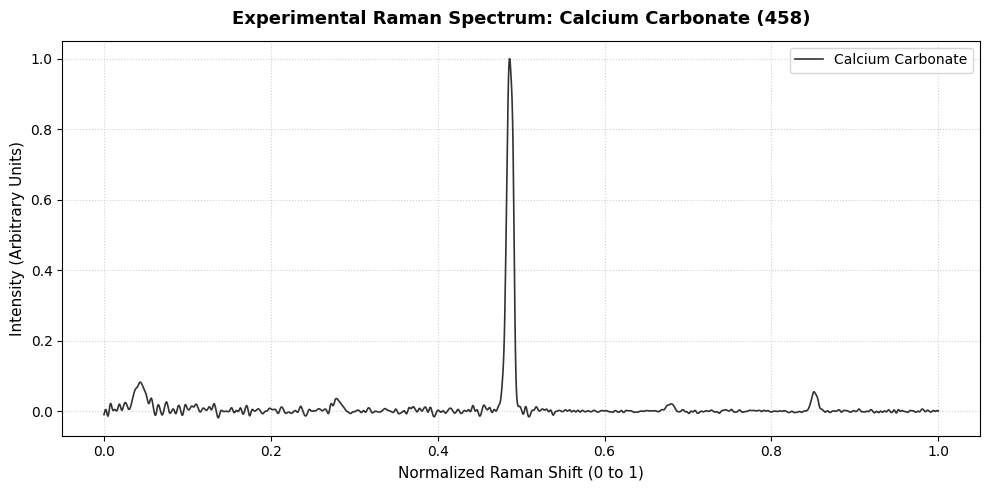

Total processed data points: 1816


In [65]:
import csv
import numpy as np
import matplotlib.pyplot as plt

data = []

with open('real_examples/csvs/CalciumCarbonate-458.csv', mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        data.append(row)

points = data[16:]
x = np.zeros(len(points))
y = np.zeros(len(points))
for i in range(len(points)):
    x[i] += np.float32(points[i][0])
    y[i] += np.float32(points[i][1])

cropped_x = x[:1816]
target_x = np.linspace(0, 1, len(cropped_x))
target_y = y[:1816]

# --- PLOTTING, LABELLING, AND SAVING ---
plt.figure(figsize=(10, 5))
plt.plot(target_x, target_y, color='black', linewidth=1.2, alpha=0.8, label='Calcium Carbonate')

# Add descriptive titles and labels
plt.title("Experimental Raman Spectrum: Calcium Carbonate (458)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Normalized Raman Shift (0 to 1)", fontsize=11)
plt.ylabel("Intensity (Arbitrary Units)", fontsize=11)

# Add clean styling elements
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

# Save the spectrum plot as a high-resolution image file
output_filename = "calcium_carbonate_raw_spectrum.png"
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"Spectrum plot cleanly rendered and saved to '{output_filename}'")

# Display the output window
plt.show()

print(f"Total processed data points: {len(target_y)}")

In [66]:
import csv
import time
import heapq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lmfit import Model, Parameters

def lorentzian(x, x0, gamma, maximum):
    gamma_sq = gamma ** 2
    return (maximum * gamma_sq) / (gamma_sq + (x - x0)**2)

def composite_lorentzian_model(x, **params):
    """Sums multiple Lorentzians based on parameter prefixes (p0_, p1_, etc.)"""
    y = np.zeros_like(x)
    prefixes = sorted(set(p.split('_')[0] for p in params.keys()))
    for pref in prefixes:
        y += lorentzian(x, params[f'{pref}_x0'], params[f'{pref}_gamma'], params[f'{pref}_maximum'])
    return y

# =====================================================================
# 1. OPTIMIZER WRAPPERS & FORMATTING
# =====================================================================

def fit_raman_spectrum(target_x, target_y, num_peaks, base_parameters, method='differential_evolution'):
    """
    Fits a cropped/normalized spectrum using standard lmfit global optimization algorithms.
    """
    model = Model(composite_lorentzian_model)
    pars = Parameters()
    
    for i in range(num_peaks):
        pref = f"p{i}_"
        init_x0 = (base_parameters["center_range"][0] + base_parameters["center_range"][1]) / 2
        init_gamma = (base_parameters["gamma_range"][0] + base_parameters["gamma_range"][1]) / 2
        init_max = (base_parameters["amplitude_range"][0] + base_parameters["amplitude_range"][1]) / 2
        
        pars.add(f"{pref}x0", value=init_x0, min=base_parameters["center_range"][0], max=base_parameters["center_range"][1])
        pars.add(f"{pref}gamma", value=init_gamma, min=base_parameters["gamma_range"][0], max=base_parameters["gamma_range"][1])
        pars.add(f"{pref}maximum", value=init_max, min=base_parameters["amplitude_range"][0], max=base_parameters["amplitude_range"][1])
        
    res = model.fit(target_y, pars, x=target_x, method=method, calc_covar=False)
    
    fitted_peaks = []
    best_values = res.params.valuesdict()
    for i in range(num_peaks):
        pref = f"p{i}_"
        fitted_peaks.append({
            "peak_id": i,
            "center": best_values[f"{pref}x0"],
            "gamma": best_values[f"{pref}gamma"],
            "amplitude": best_values[f"{pref}maximum"]
        })
        
    return fitted_peaks

def fit_with_custom_knn_pipeline(target_x, target_y, num_peaks, base_parameters, samples=1000, k=5, rounds=4, eps=0.15):
    """
    Wraps your custom persistent KNN stage followed by Levenberg-Marquardt local refinement.
    """
    # Execute Stage 1: Core KNN Global Search Space Approximation
    _, neighbors = knnFit_persistent(
        samples=samples, base_parameters=base_parameters, target_x=target_x, 
        target_y=target_y, num_peaks=num_peaks, k=k, rounds=rounds, eps=eps
    )
    
    # Execute Stage 2: Sub-domain Optimization Refinement via Levenberg-Marquardt
    best_res, nfe = refine_knn_with_lmfit(neighbors, target_x, target_y)
    
    # Parse lmfit ModelResult structure back to aligned peak lists
    fitted_peaks = []
    best_values = best_res.params.valuesdict()
    for i in range(num_peaks):
        pref = f"p{i}_"
        fitted_peaks.append({
            "peak_id": i,
            "center": best_values[f"{pref}x0"],
            "gamma": best_values[f"{pref}gamma"],
            "amplitude": best_values[f"{pref}maximum"]
        })
        
    return fitted_peaks

def print_formatted_peaks(method_name, runtime, peaks):
    """Prints optimization output in a beautiful, structured table format."""
    print("\n" + "="*50)
    print(f" METHOD: {method_name}")
    print(f" Runtime: {runtime:.4f} seconds")
    print("-"*50)
    print(f"{'Peak ID':<10} | {'Center (x0)':<12} | {'Gamma (γ)':<10} | {'Amplitude':<10}")
    print("-"*50)
    for p in peaks:
        print(f"Peak {p['peak_id']:<5} | {p['center']:<12.5f} | {p['gamma']:<10.5f} | {p['amplitude']:<10.5f}")
    print("="*50)

In [67]:
raman_params = {
    "center_range": (0.1, 0.9),
    "amplitude_range": (0.01, 1.0),
    "gamma_range": (0.003, 0.05),
    "x_min": 0,
    "x_max": 1
}

num_peaks_to_find = 4

# --- Solver 1: Differential Evolution ---
print("Running Differential Evolution...")
t0 = time.perf_counter()
de_peaks = fit_raman_spectrum(
    target_x=target_x, target_y=target_y, num_peaks=num_peaks_to_find,
    base_parameters=raman_params, method='differential_evolution'
)
de_runtime = time.perf_counter() - t0
print_formatted_peaks("Differential Evolution", de_runtime, de_peaks)


# --- Solver 2: Dual Annealing ---
print("\nRunning Dual Annealing...")
t0 = time.perf_counter()
da_peaks = fit_raman_spectrum(
    target_x=target_x, target_y=target_y, num_peaks=num_peaks_to_find,
    base_parameters=raman_params, method='dual_annealing'
)
da_runtime = time.perf_counter() - t0
print_formatted_peaks("Dual Annealing", da_runtime, da_peaks)


# --- Solver 3: Your Custom KNN + LM Refinement ---
print("\nRunning Custom KNN + LM Pipeline...")
t0 = time.perf_counter()
knn_peaks = fit_with_custom_knn_pipeline(
    target_x=target_x, target_y=target_y, num_peaks=num_peaks_to_find,
    base_parameters=raman_params, samples=1000, k=5, rounds=4, eps=0.15
)
knn_runtime = time.perf_counter() - t0
print_formatted_peaks("KNN + LM Refinement", knn_runtime, knn_peaks)

Running Differential Evolution...

 METHOD: Differential Evolution
 Runtime: 5.1515 seconds
--------------------------------------------------
Peak ID    | Center (x0)  | Gamma (γ)  | Amplitude 
--------------------------------------------------
Peak 0     | 0.48663      | 0.00399    | 1.00000   
Peak 1     | 0.27927      | 0.00395    | 0.03689   
Peak 2     | 0.85159      | 0.00339    | 0.05990   
Peak 3     | 0.10000      | 0.05000    | 0.01396   

Running Dual Annealing...

 METHOD: Dual Annealing
 Runtime: 6.4289 seconds
--------------------------------------------------
Peak ID    | Center (x0)  | Gamma (γ)  | Amplitude 
--------------------------------------------------
Peak 0     | 0.48491      | 0.00300    | 0.69284   
Peak 1     | 0.85159      | 0.00339    | 0.05991   
Peak 2     | 0.27926      | 0.00439    | 0.03704   
Peak 3     | 0.48857      | 0.00300    | 0.64282   

Running Custom KNN + LM Pipeline...

 METHOD: KNN + LM Refinement
 Runtime: 0.5461 seconds
---------------

In [68]:
def plot_and_save_unified_grid(target_x, target_y, de_peaks, da_peaks, knn_peaks, filename="raman_solvers_grid.png"):
    """
    Plots the real data against the final model fits for all three optimization methods 
    side-by-side in a single row layout, then saves the complete grid as one unified image.
    
    Args:
        target_x (array): The normalized X-axis range array.
        target_y (array): The experimental normalized spectrum intensity values.
        de_peaks (list): Fitted parameters list from Differential Evolution.
        da_peaks (list): Fitted parameters list from Dual Annealing.
        knn_peaks (list): Fitted parameters list from your Custom KNN pipeline.
        filename (str): Output image filename path.
    """
    # Create a single figure canvas composed of 1 row and 3 columns of subplots
    # sharey=True forces all windows to use the exact same Y-axis scale for fairness
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    
    # Map configurations for iterating dynamically through the subplot columns
    methods_config = [
        {"name": "Differential Evolution", "peaks": de_peaks, "color": "#1f77b4"},
        {"name": "Dual Annealing", "peaks": da_peaks, "color": "#2ca02c"},
        {"name": "Adaptive kNN + LM refinement", "peaks": knn_peaks, "color": "#d62728"}
    ]
    
    for idx, config in enumerate(methods_config):
        ax = axes[idx] # Focus on the active column subplot window
        
        # 1. Plot the common background raw experimental line reference
        ax.plot(target_x, target_y, color='black', alpha=0.35, linewidth=1.2, label='Experimental Data')
        
        # 2. Re-calculate the specific solver's total integrated curve array
        total_fitted_y = np.zeros_like(target_x)
        for p in config["peaks"]:
            total_fitted_y += lorentzian(target_x, p['center'], p['gamma'], p['amplitude'])
            
        # 3. Overlay the clean continuous model fit on top
        ax.plot(target_x, total_fitted_y, color=config["color"], linewidth=2, label='Final Model Fit')
        
        # 4. Styling individual sub-windows
        ax.set_title(config["name"], fontsize=12, fontweight='bold')
        ax.set_xlabel("Normalized Raman Shift", fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.5)
        
        # Place a separate, clean legend in the upper right corner of each panel
        ax.legend(loc='upper right', frameon=True, fontsize=9)
        
    # Apply standard Y-axis label specifically to the first column panel
    axes[0].set_ylabel("Normalized Intensity", fontsize=11)
    
    # Global overall chart adjustments
    plt.suptitle("Raman Solver Performance Comparison - Calcium Carbonate", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save the entire grid layout securely to a single high-resolution file
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Successfully compiled grid canvas and saved image to '{filename}'")
    
    plt.show()

Successfully compiled grid canvas and saved image to 'calcium_sulfate_grid_comparison.png'


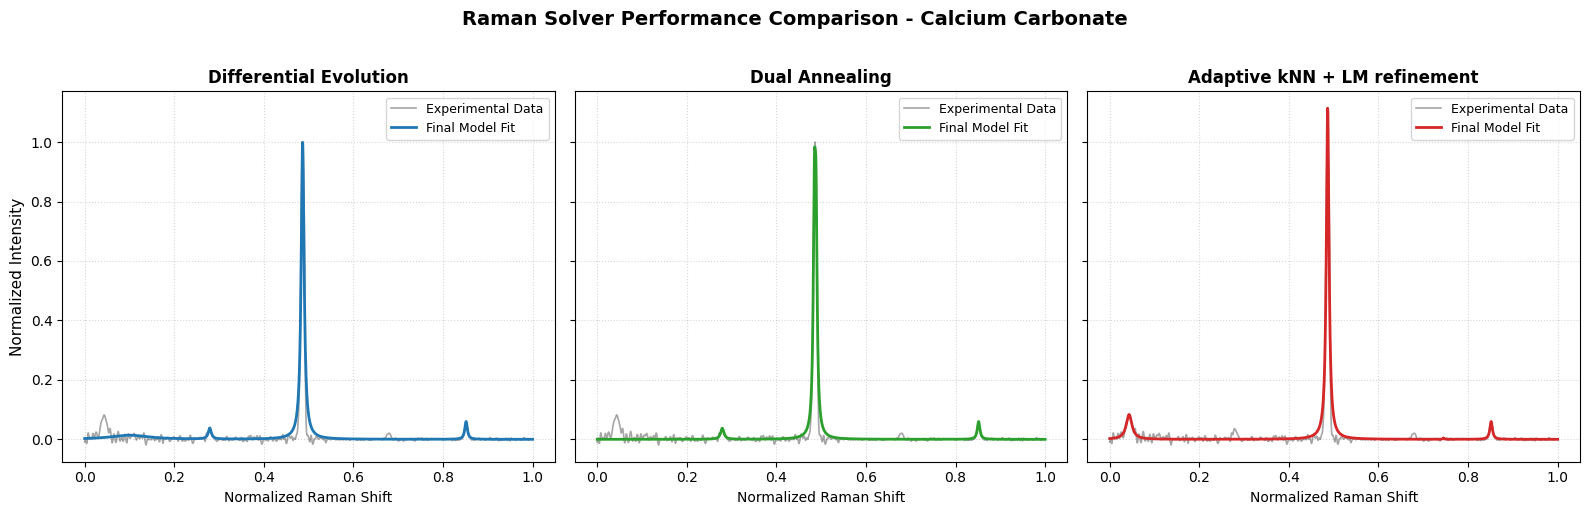

In [69]:
# ... [Your script running Solver 1, Solver 2, and Solver 3]

# Generate the single unified grid image file
plot_and_save_unified_grid(
    target_x=target_x,
    target_y=target_y,
    de_peaks=de_peaks,
    da_peaks=da_peaks,
    knn_peaks=knn_peaks,
    filename="calcium_sulfate_grid_comparison.png"
)

# Real Examples - Calcium Sulfate 1

Spectrum plot cleanly rendered and saved to 'calcium_carbonate_raw_spectrum.png'


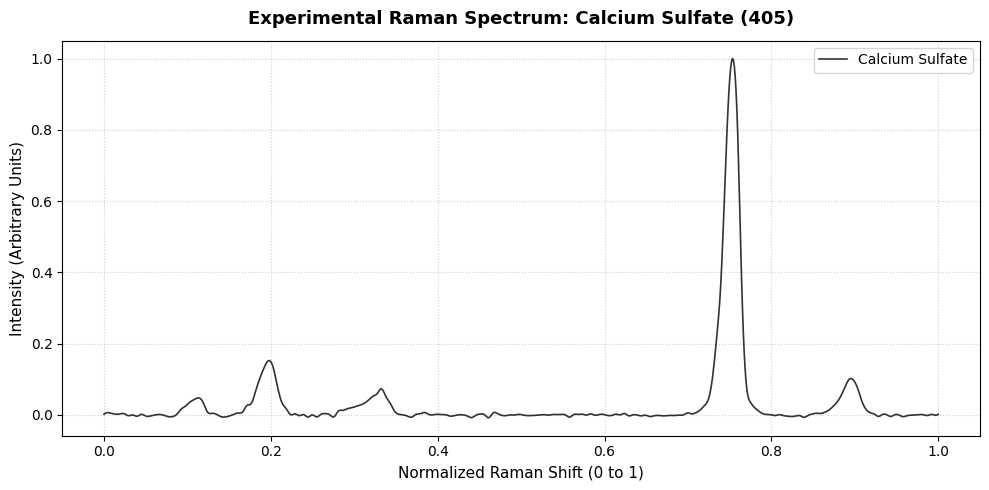

Total processed data points: 925


In [70]:
import csv
import numpy as np
import matplotlib.pyplot as plt

data = []

with open('real_examples/csvs/CalciumSulfate_405.csv', mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        data.append(row)

points = data[16:]
x = np.zeros(len(points))
y = np.zeros(len(points))
for i in range(len(points)):
    x[i] += np.float32(points[i][0])
    y[i] += np.float32(points[i][1])

cropped_x = x[110:1035]
target_x = np.linspace(0, 1, len(cropped_x))
target_y = y[110:1035]

# --- PLOTTING, LABELLING, AND SAVING ---
plt.figure(figsize=(10, 5))
plt.plot(target_x, target_y, color='black', linewidth=1.2, alpha=0.8, label='Calcium Sulfate')

# Add descriptive titles and labels
plt.title("Experimental Raman Spectrum: Calcium Sulfate (405)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Normalized Raman Shift (0 to 1)", fontsize=11)
plt.ylabel("Intensity (Arbitrary Units)", fontsize=11)

# Add clean styling elements
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

# Save the spectrum plot as a high-resolution image file
output_filename = "calcium_sulfate_raw_spectrum.png"
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"Spectrum plot cleanly rendered and saved to '{output_filename}'")

# Display the output window
plt.show()

print(f"Total processed data points: {len(target_y)}")

In [81]:
import csv
import time
import heapq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lmfit import Model, Parameters

def lorentzian(x, x0, gamma, maximum):
    gamma_sq = gamma ** 2
    return (maximum * gamma_sq) / (gamma_sq + (x - x0)**2)

def composite_lorentzian_model(x, **params):
    """Sums multiple Lorentzians based on parameter prefixes (p0_, p1_, etc.)"""
    y = np.zeros_like(x)
    prefixes = sorted(set(p.split('_')[0] for p in params.keys()))
    for pref in prefixes:
        y += lorentzian(x, params[f'{pref}_x0'], params[f'{pref}_gamma'], params[f'{pref}_maximum'])
    return y

# =====================================================================
# 1. OPTIMIZER WRAPPERS & FORMATTING
# =====================================================================

def fit_raman_spectrum(target_x, target_y, num_peaks, base_parameters, method='differential_evolution'):
    """
    Fits a cropped/normalized spectrum using standard lmfit global optimization algorithms.
    """
    model = Model(composite_lorentzian_model)
    pars = Parameters()
    
    for i in range(num_peaks):
        pref = f"p{i}_"
        init_x0 = (base_parameters["center_range"][0] + base_parameters["center_range"][1]) / 2
        init_gamma = (base_parameters["gamma_range"][0] + base_parameters["gamma_range"][1]) / 2
        init_max = (base_parameters["amplitude_range"][0] + base_parameters["amplitude_range"][1]) / 2
        
        pars.add(f"{pref}x0", value=init_x0, min=base_parameters["center_range"][0], max=base_parameters["center_range"][1])
        pars.add(f"{pref}gamma", value=init_gamma, min=base_parameters["gamma_range"][0], max=base_parameters["gamma_range"][1])
        pars.add(f"{pref}maximum", value=init_max, min=base_parameters["amplitude_range"][0], max=base_parameters["amplitude_range"][1])
        
    res = model.fit(target_y, pars, x=target_x, method=method, calc_covar=False)
    
    fitted_peaks = []
    best_values = res.params.valuesdict()
    for i in range(num_peaks):
        pref = f"p{i}_"
        fitted_peaks.append({
            "peak_id": i,
            "center": best_values[f"{pref}x0"],
            "gamma": best_values[f"{pref}gamma"],
            "amplitude": best_values[f"{pref}maximum"]
        })
        
    return fitted_peaks

def fit_with_custom_knn_pipeline(target_x, target_y, num_peaks, base_parameters, samples=1000, k=5, rounds=4, eps=0.15):
    """
    Wraps your custom persistent KNN stage followed by Levenberg-Marquardt local refinement.
    """
    # Execute Stage 1: Core KNN Global Search Space Approximation
    _, neighbors = knnFit_persistent(
        samples=samples, base_parameters=base_parameters, target_x=target_x, 
        target_y=target_y, num_peaks=num_peaks, k=k, rounds=rounds, eps=eps
    )
    
    # Execute Stage 2: Sub-domain Optimization Refinement via Levenberg-Marquardt
    best_res, nfe = refine_knn_with_lmfit(neighbors, target_x, target_y)
    
    # Parse lmfit ModelResult structure back to aligned peak lists
    fitted_peaks = []
    best_values = best_res.params.valuesdict()
    for i in range(num_peaks):
        pref = f"p{i}_"
        fitted_peaks.append({
            "peak_id": i,
            "center": best_values[f"{pref}x0"],
            "gamma": best_values[f"{pref}gamma"],
            "amplitude": best_values[f"{pref}maximum"]
        })
        
    return fitted_peaks

def print_formatted_peaks(method_name, runtime, peaks):
    """Prints optimization output in a beautiful, structured table format."""
    print("\n" + "="*50)
    print(f" METHOD: {method_name}")
    print(f" Runtime: {runtime:.4f} seconds")
    print("-"*50)
    print(f"{'Peak ID':<10} | {'Center (x0)':<12} | {'Gamma (γ)':<10} | {'Amplitude':<10}")
    print("-"*50)
    for p in peaks:
        print(f"Peak {p['peak_id']:<5} | {p['center']:<12.5f} | {p['gamma']:<10.5f} | {p['amplitude']:<10.5f}")
    print("="*50)

In [88]:
raman_params = {
    "center_range": (0.1, 0.9),
    "amplitude_range": (0.01, 1.0),
    "gamma_range": (0.003, 0.05),
    "x_min": 0,
    "x_max": 1
}

num_peaks_to_find = 5

# --- Solver 1: Differential Evolution ---
print("Running Differential Evolution...")
t0 = time.perf_counter()
de_peaks = fit_raman_spectrum(
    target_x=target_x, target_y=target_y, num_peaks=num_peaks_to_find,
    base_parameters=raman_params, method='differential_evolution'
)
de_runtime = time.perf_counter() - t0
print_formatted_peaks("Differential Evolution", de_runtime, de_peaks)


# --- Solver 2: Dual Annealing ---
print("\nRunning Dual Annealing...")
t0 = time.perf_counter()
da_peaks = fit_raman_spectrum(
    target_x=target_x, target_y=target_y, num_peaks=num_peaks_to_find,
    base_parameters=raman_params, method='dual_annealing'
)
da_runtime = time.perf_counter() - t0
print_formatted_peaks("Dual Annealing", da_runtime, da_peaks)


# --- Solver 3: Your Custom KNN + LM Refinement ---
print("\nRunning Custom KNN + LM Pipeline...")
t0 = time.perf_counter()
knn_peaks = fit_with_custom_knn_pipeline(
    target_x=target_x, target_y=target_y, num_peaks=num_peaks_to_find,
    base_parameters=raman_params, samples=1000, k=5, rounds=4, eps=0.15
)
knn_runtime = time.perf_counter() - t0
print_formatted_peaks("KNN + LM Refinement", knn_runtime, knn_peaks)

Running Differential Evolution...

 METHOD: Differential Evolution
 Runtime: 8.0853 seconds
--------------------------------------------------
Peak ID    | Center (x0)  | Gamma (γ)  | Amplitude 
--------------------------------------------------
Peak 0     | 0.32529      | 0.01067    | 0.02322   
Peak 1     | 0.19548      | 0.01167    | 0.16269   
Peak 2     | 0.88881      | 0.02412    | 0.04491   
Peak 3     | 0.75201      | 0.00852    | 0.98794   
Peak 4     | 0.89818      | 0.00900    | 0.08835   

Running Dual Annealing...

 METHOD: Dual Annealing
 Runtime: 7.9335 seconds
--------------------------------------------------
Peak ID    | Center (x0)  | Gamma (γ)  | Amplitude 
--------------------------------------------------
Peak 0     | 0.19622      | 0.01024    | 0.16266   
Peak 1     | 0.89501      | 0.00875    | 0.10997   
Peak 2     | 0.32856      | 0.01206    | 0.06951   
Peak 3     | 0.74841      | 0.00700    | 0.75029   
Peak 4     | 0.75708      | 0.00495    | 0.69359   

Ru

In [89]:
def plot_and_save_unified_grid(target_x, target_y, de_peaks, da_peaks, knn_peaks, filename="raman_solvers_grid.png"):
    """
    Plots the real data against the final model fits for all three optimization methods 
    side-by-side in a single row layout, then saves the complete grid as one unified image.
    
    Args:
        target_x (array): The normalized X-axis range array.
        target_y (array): The experimental normalized spectrum intensity values.
        de_peaks (list): Fitted parameters list from Differential Evolution.
        da_peaks (list): Fitted parameters list from Dual Annealing.
        knn_peaks (list): Fitted parameters list from your Custom KNN pipeline.
        filename (str): Output image filename path.
    """
    # Create a single figure canvas composed of 1 row and 3 columns of subplots
    # sharey=True forces all windows to use the exact same Y-axis scale for fairness
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    
    # Map configurations for iterating dynamically through the subplot columns
    methods_config = [
        {"name": "Differential Evolution", "peaks": de_peaks, "color": "#1f77b4"},
        {"name": "Dual Annealing", "peaks": da_peaks, "color": "#2ca02c"},
        {"name": "Adaptive kNN + LM refinement", "peaks": knn_peaks, "color": "#d62728"}
    ]
    
    for idx, config in enumerate(methods_config):
        ax = axes[idx] # Focus on the active column subplot window
        
        # 1. Plot the common background raw experimental line reference
        ax.plot(target_x, target_y, color='black', alpha=0.35, linewidth=1.2, label='Experimental Data')
        
        # 2. Re-calculate the specific solver's total integrated curve array
        total_fitted_y = np.zeros_like(target_x)
        for p in config["peaks"]:
            total_fitted_y += lorentzian(target_x, p['center'], p['gamma'], p['amplitude'])
            
        # 3. Overlay the clean continuous model fit on top
        ax.plot(target_x, total_fitted_y, color=config["color"], linewidth=2, label='Final Model Fit')
        
        # 4. Styling individual sub-windows
        ax.set_title(config["name"], fontsize=12, fontweight='bold')
        ax.set_xlabel("Normalized Raman Shift", fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.5)
        
        # Place a separate, clean legend in the upper right corner of each panel
        ax.legend(loc='upper right', frameon=True, fontsize=9)
        
    # Apply standard Y-axis label specifically to the first column panel
    axes[0].set_ylabel("Normalized Intensity", fontsize=11)
    
    # Global overall chart adjustments
    plt.suptitle("Raman Solver Performance Comparison - Calcium Sulfate", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save the entire grid layout securely to a single high-resolution file
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Successfully compiled grid canvas and saved image to '{filename}'")
    
    plt.show()

Successfully compiled grid canvas and saved image to 'calcium_sulfate_grid_comparison.png'


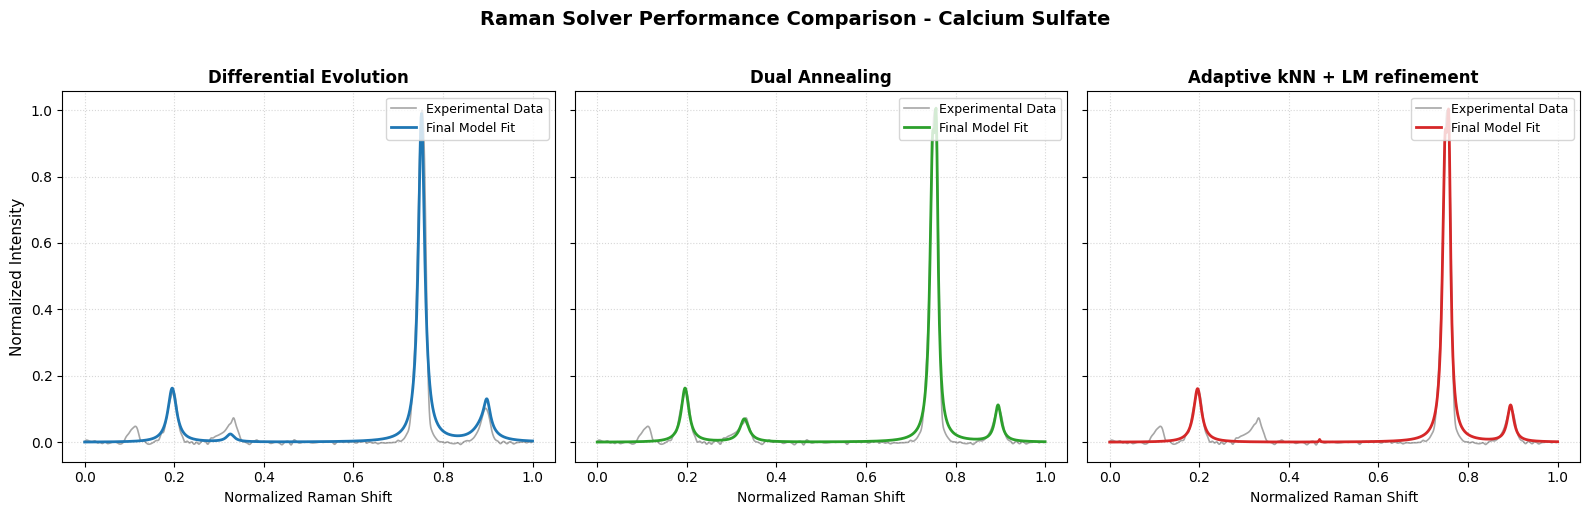

In [90]:
# ... [Your script running Solver 1, Solver 2, and Solver 3]

# Generate the single unified grid image file
plot_and_save_unified_grid(
    target_x=target_x,
    target_y=target_y,
    de_peaks=de_peaks,
    da_peaks=da_peaks,
    knn_peaks=knn_peaks,
    filename="calcium_sulfate_grid_comparison.png"
)

# Calcium Sulfate - 2

Spectrum plot cleanly rendered and saved to 'calcium_sulfate_raw_spectrum.png'


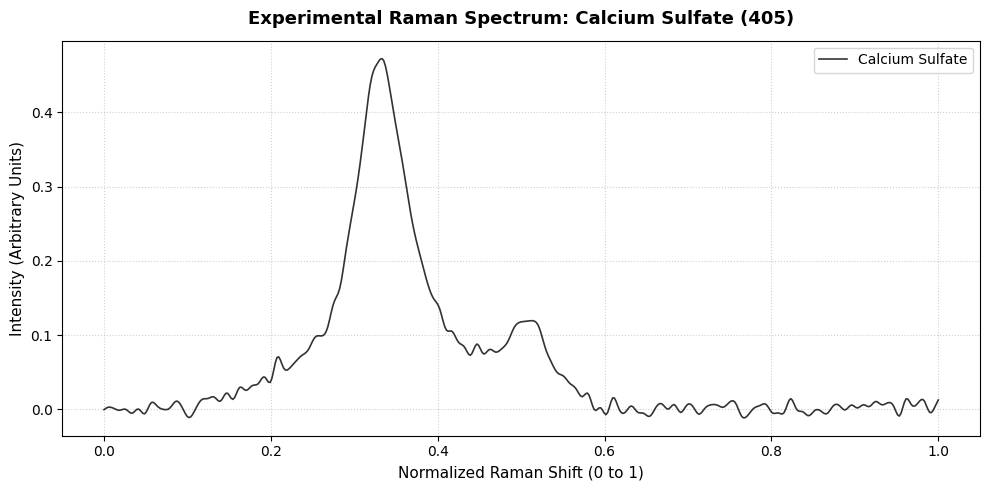

Total processed data points: 493


In [99]:
import csv
import numpy as np
import matplotlib.pyplot as plt

data = []

with open('real_examples/csvs/CalciumSulfate_405.csv', mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        data.append(row)

points = data[16:]
x = np.zeros(len(points))
y = np.zeros(len(points))
for i in range(len(points)):
    x[i] += np.float32(points[i][0])
    y[i] += np.float32(points[i][1])

cropped_x = x[3037:3530]
target_x = np.linspace(0, 1, len(cropped_x))
target_y = y[3037:3530]

# --- PLOTTING, LABELLING, AND SAVING ---
plt.figure(figsize=(10, 5))
plt.plot(target_x, target_y, color='black', linewidth=1.2, alpha=0.8, label='Calcium Sulfate')

# Add descriptive titles and labels
plt.title("Experimental Raman Spectrum: Calcium Sulfate (405)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Normalized Raman Shift (0 to 1)", fontsize=11)
plt.ylabel("Intensity (Arbitrary Units)", fontsize=11)

# Add clean styling elements
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

# Save the spectrum plot as a high-resolution image file
output_filename = "calcium_sulfate_raw_spectrum.png"
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"Spectrum plot cleanly rendered and saved to '{output_filename}'")

# Display the output window
plt.show()

print(f"Total processed data points: {len(target_y)}")

In [100]:
import csv
import time
import heapq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lmfit import Model, Parameters

def lorentzian(x, x0, gamma, maximum):
    gamma_sq = gamma ** 2
    return (maximum * gamma_sq) / (gamma_sq + (x - x0)**2)

def composite_lorentzian_model(x, **params):
    """Sums multiple Lorentzians based on parameter prefixes (p0_, p1_, etc.)"""
    y = np.zeros_like(x)
    prefixes = sorted(set(p.split('_')[0] for p in params.keys()))
    for pref in prefixes:
        y += lorentzian(x, params[f'{pref}_x0'], params[f'{pref}_gamma'], params[f'{pref}_maximum'])
    return y

# =====================================================================
# 1. OPTIMIZER WRAPPERS & FORMATTING
# =====================================================================

def fit_raman_spectrum(target_x, target_y, num_peaks, base_parameters, method='differential_evolution'):
    """
    Fits a cropped/normalized spectrum using standard lmfit global optimization algorithms.
    """
    model = Model(composite_lorentzian_model)
    pars = Parameters()
    
    for i in range(num_peaks):
        pref = f"p{i}_"
        init_x0 = (base_parameters["center_range"][0] + base_parameters["center_range"][1]) / 2
        init_gamma = (base_parameters["gamma_range"][0] + base_parameters["gamma_range"][1]) / 2
        init_max = (base_parameters["amplitude_range"][0] + base_parameters["amplitude_range"][1]) / 2
        
        pars.add(f"{pref}x0", value=init_x0, min=base_parameters["center_range"][0], max=base_parameters["center_range"][1])
        pars.add(f"{pref}gamma", value=init_gamma, min=base_parameters["gamma_range"][0], max=base_parameters["gamma_range"][1])
        pars.add(f"{pref}maximum", value=init_max, min=base_parameters["amplitude_range"][0], max=base_parameters["amplitude_range"][1])
        
    res = model.fit(target_y, pars, x=target_x, method=method, calc_covar=False)
    
    fitted_peaks = []
    best_values = res.params.valuesdict()
    for i in range(num_peaks):
        pref = f"p{i}_"
        fitted_peaks.append({
            "peak_id": i,
            "center": best_values[f"{pref}x0"],
            "gamma": best_values[f"{pref}gamma"],
            "amplitude": best_values[f"{pref}maximum"]
        })
        
    return fitted_peaks

def fit_with_custom_knn_pipeline(target_x, target_y, num_peaks, base_parameters, samples=1000, k=5, rounds=4, eps=0.15):
    """
    Wraps your custom persistent KNN stage followed by Levenberg-Marquardt local refinement.
    """
    # Execute Stage 1: Core KNN Global Search Space Approximation
    _, neighbors = knnFit_persistent(
        samples=samples, base_parameters=base_parameters, target_x=target_x, 
        target_y=target_y, num_peaks=num_peaks, k=k, rounds=rounds, eps=eps
    )
    
    # Execute Stage 2: Sub-domain Optimization Refinement via Levenberg-Marquardt
    best_res, nfe = refine_knn_with_lmfit(neighbors, target_x, target_y)
    
    # Parse lmfit ModelResult structure back to aligned peak lists
    fitted_peaks = []
    best_values = best_res.params.valuesdict()
    for i in range(num_peaks):
        pref = f"p{i}_"
        fitted_peaks.append({
            "peak_id": i,
            "center": best_values[f"{pref}x0"],
            "gamma": best_values[f"{pref}gamma"],
            "amplitude": best_values[f"{pref}maximum"]
        })
        
    return fitted_peaks

def print_formatted_peaks(method_name, runtime, peaks):
    """Prints optimization output in a beautiful, structured table format."""
    print("\n" + "="*50)
    print(f" METHOD: {method_name}")
    print(f" Runtime: {runtime:.4f} seconds")
    print("-"*50)
    print(f"{'Peak ID':<10} | {'Center (x0)':<12} | {'Gamma (γ)':<10} | {'Amplitude':<10}")
    print("-"*50)
    for p in peaks:
        print(f"Peak {p['peak_id']:<5} | {p['center']:<12.5f} | {p['gamma']:<10.5f} | {p['amplitude']:<10.5f}")
    print("="*50)

In [102]:
raman_params = {
    "center_range": (0.1, 0.9),
    "amplitude_range": (0.01, 1.0),
    "gamma_range": (0.003, 0.05),
    "x_min": 0,
    "x_max": 1
}

num_peaks_to_find = 2

# --- Solver 1: Differential Evolution ---
print("Running Differential Evolution...")
t0 = time.perf_counter()
de_peaks = fit_raman_spectrum(
    target_x=target_x, target_y=target_y, num_peaks=num_peaks_to_find,
    base_parameters=raman_params, method='differential_evolution'
)
de_runtime = time.perf_counter() - t0
print_formatted_peaks("Differential Evolution", de_runtime, de_peaks)


# --- Solver 2: Dual Annealing ---
print("\nRunning Dual Annealing...")
t0 = time.perf_counter()
da_peaks = fit_raman_spectrum(
    target_x=target_x, target_y=target_y, num_peaks=num_peaks_to_find,
    base_parameters=raman_params, method='dual_annealing'
)
da_runtime = time.perf_counter() - t0
print_formatted_peaks("Dual Annealing", da_runtime, da_peaks)


# --- Solver 3: Your Custom KNN + LM Refinement ---
print("\nRunning Custom KNN + LM Pipeline...")
t0 = time.perf_counter()
knn_peaks = fit_with_custom_knn_pipeline(
    target_x=target_x, target_y=target_y, num_peaks=num_peaks_to_find,
    base_parameters=raman_params, samples=1000, k=5, rounds=4, eps=0.15
)
knn_runtime = time.perf_counter() - t0
print_formatted_peaks("KNN + LM Refinement", knn_runtime, knn_peaks)

Running Differential Evolution...

 METHOD: Differential Evolution
 Runtime: 0.7578 seconds
--------------------------------------------------
Peak ID    | Center (x0)  | Gamma (γ)  | Amplitude 
--------------------------------------------------
Peak 0     | 0.50529      | 0.02795    | 0.10320   
Peak 1     | 0.33259      | 0.03933    | 0.46810   

Running Dual Annealing...

 METHOD: Dual Annealing
 Runtime: 1.7223 seconds
--------------------------------------------------
Peak ID    | Center (x0)  | Gamma (γ)  | Amplitude 
--------------------------------------------------
Peak 0     | 0.33259      | 0.03933    | 0.46810   
Peak 1     | 0.50529      | 0.02795    | 0.10320   

Running Custom KNN + LM Pipeline...

 METHOD: KNN + LM Refinement
 Runtime: 0.1315 seconds
--------------------------------------------------
Peak ID    | Center (x0)  | Gamma (γ)  | Amplitude 
--------------------------------------------------
Peak 0     | 0.50529      | 0.02795    | 0.10320   
Peak 1     | 0.33

In [103]:
def plot_and_save_unified_grid(target_x, target_y, de_peaks, da_peaks, knn_peaks, filename="raman_solvers_grid.png"):
    """
    Plots the real data against the final model fits for all three optimization methods 
    side-by-side in a single row layout, then saves the complete grid as one unified image.
    
    Args:
        target_x (array): The normalized X-axis range array.
        target_y (array): The experimental normalized spectrum intensity values.
        de_peaks (list): Fitted parameters list from Differential Evolution.
        da_peaks (list): Fitted parameters list from Dual Annealing.
        knn_peaks (list): Fitted parameters list from your Custom KNN pipeline.
        filename (str): Output image filename path.
    """
    # Create a single figure canvas composed of 1 row and 3 columns of subplots
    # sharey=True forces all windows to use the exact same Y-axis scale for fairness
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    
    # Map configurations for iterating dynamically through the subplot columns
    methods_config = [
        {"name": "Differential Evolution", "peaks": de_peaks, "color": "#1f77b4"},
        {"name": "Dual Annealing", "peaks": da_peaks, "color": "#2ca02c"},
        {"name": "Adaptive kNN + LM refinement", "peaks": knn_peaks, "color": "#d62728"}
    ]
    
    for idx, config in enumerate(methods_config):
        ax = axes[idx] # Focus on the active column subplot window
        
        # 1. Plot the common background raw experimental line reference
        ax.plot(target_x, target_y, color='black', alpha=0.35, linewidth=1.2, label='Experimental Data')
        
        # 2. Re-calculate the specific solver's total integrated curve array
        total_fitted_y = np.zeros_like(target_x)
        for p in config["peaks"]:
            total_fitted_y += lorentzian(target_x, p['center'], p['gamma'], p['amplitude'])
            
        # 3. Overlay the clean continuous model fit on top
        ax.plot(target_x, total_fitted_y, color=config["color"], linewidth=2, label='Final Model Fit')
        
        # 4. Styling individual sub-windows
        ax.set_title(config["name"], fontsize=12, fontweight='bold')
        ax.set_xlabel("Normalized Raman Shift", fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.5)
        
        # Place a separate, clean legend in the upper right corner of each panel
        ax.legend(loc='upper right', frameon=True, fontsize=9)
        
    # Apply standard Y-axis label specifically to the first column panel
    axes[0].set_ylabel("Normalized Intensity", fontsize=11)
    
    # Global overall chart adjustments
    plt.suptitle("Raman Solver Performance Comparison - Calcium Sulfate", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save the entire grid layout securely to a single high-resolution file
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Successfully compiled grid canvas and saved image to '{filename}'")
    
    plt.show()

Successfully compiled grid canvas and saved image to 'calcium_sulfate_grid_comparison.png'


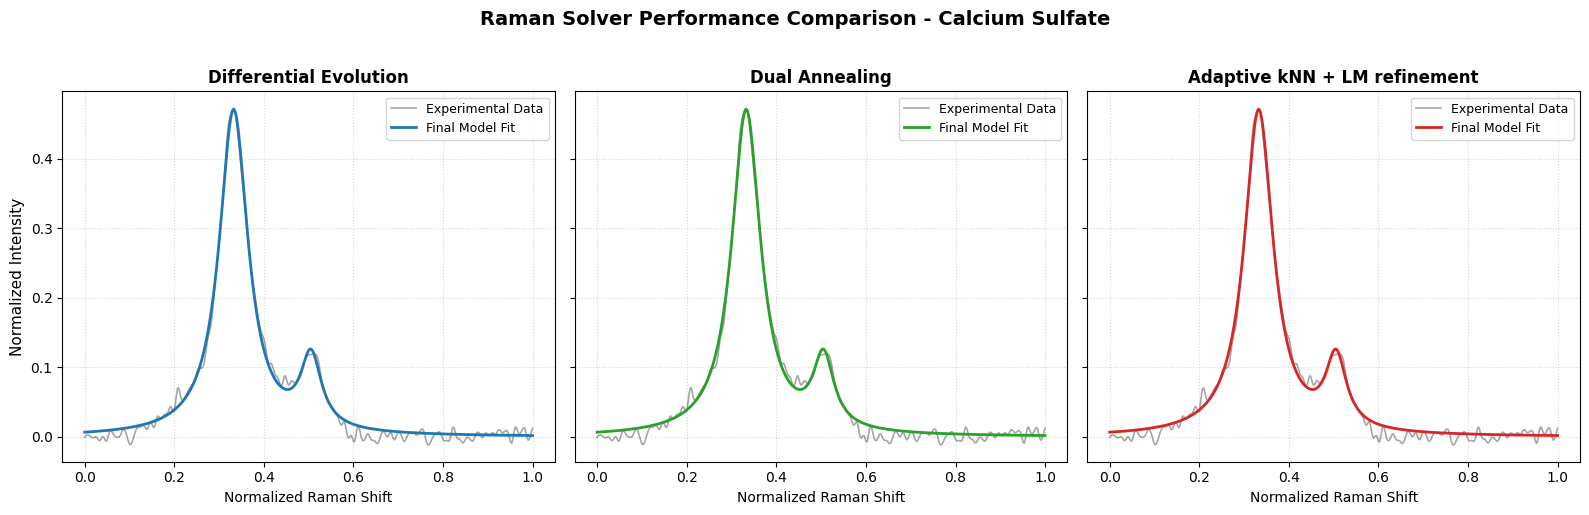

In [104]:
# ... [Your script running Solver 1, Solver 2, and Solver 3]

# Generate the single unified grid image file
plot_and_save_unified_grid(
    target_x=target_x,
    target_y=target_y,
    de_peaks=de_peaks,
    da_peaks=da_peaks,
    knn_peaks=knn_peaks,
    filename="calcium_sulfate_grid_comparison.png"
)

# Dolomite

Spectrum plot cleanly rendered and saved to 'dolomite_raw_spectrum.png'


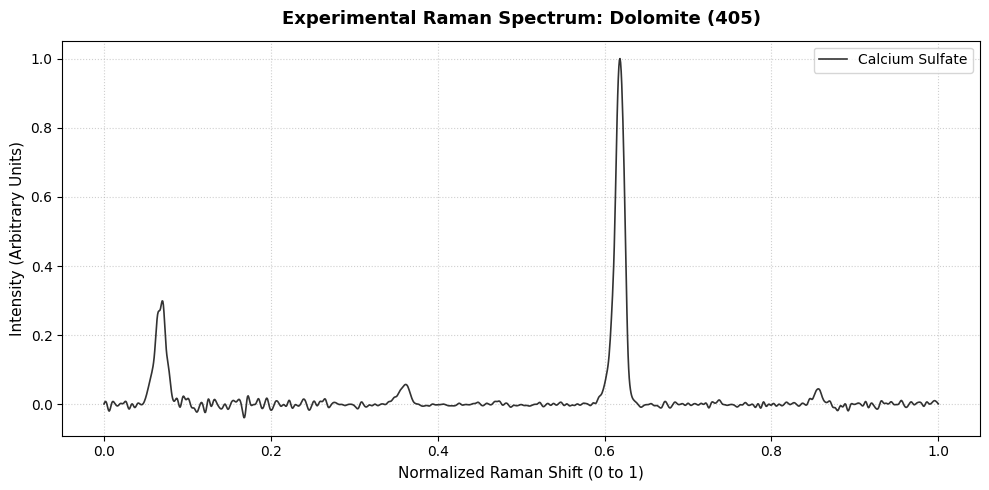

Total processed data points: 1448


In [114]:
import csv
import numpy as np
import matplotlib.pyplot as plt

data = []

with open('real_examples/csvs/Dolomite_405.csv', mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        data.append(row)

points = data[16:]
x = np.zeros(len(points))
y = np.zeros(len(points))
for i in range(len(points)):
    x[i] += np.float32(points[i][0])
    y[i] += np.float32(points[i][1])

cropped_x = x[:1448]
target_x = np.linspace(0, 1, len(cropped_x))
target_y = y[:1448]

# --- PLOTTING, LABELLING, AND SAVING ---
plt.figure(figsize=(10, 5))
plt.plot(target_x, target_y, color='black', linewidth=1.2, alpha=0.8, label='Calcium Sulfate')

# Add descriptive titles and labels
plt.title("Experimental Raman Spectrum: Dolomite (405)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Normalized Raman Shift (0 to 1)", fontsize=11)
plt.ylabel("Intensity (Arbitrary Units)", fontsize=11)

# Add clean styling elements
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

# Save the spectrum plot as a high-resolution image file
output_filename = "dolomite_raw_spectrum.png"
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"Spectrum plot cleanly rendered and saved to '{output_filename}'")

# Display the output window
plt.show()

print(f"Total processed data points: {len(target_y)}")

In [107]:
import csv
import time
import heapq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lmfit import Model, Parameters

def lorentzian(x, x0, gamma, maximum):
    gamma_sq = gamma ** 2
    return (maximum * gamma_sq) / (gamma_sq + (x - x0)**2)

def composite_lorentzian_model(x, **params):
    """Sums multiple Lorentzians based on parameter prefixes (p0_, p1_, etc.)"""
    y = np.zeros_like(x)
    prefixes = sorted(set(p.split('_')[0] for p in params.keys()))
    for pref in prefixes:
        y += lorentzian(x, params[f'{pref}_x0'], params[f'{pref}_gamma'], params[f'{pref}_maximum'])
    return y

# =====================================================================
# 1. OPTIMIZER WRAPPERS & FORMATTING
# =====================================================================

def fit_raman_spectrum(target_x, target_y, num_peaks, base_parameters, method='differential_evolution'):
    """
    Fits a cropped/normalized spectrum using standard lmfit global optimization algorithms.
    """
    model = Model(composite_lorentzian_model)
    pars = Parameters()
    
    for i in range(num_peaks):
        pref = f"p{i}_"
        init_x0 = (base_parameters["center_range"][0] + base_parameters["center_range"][1]) / 2
        init_gamma = (base_parameters["gamma_range"][0] + base_parameters["gamma_range"][1]) / 2
        init_max = (base_parameters["amplitude_range"][0] + base_parameters["amplitude_range"][1]) / 2
        
        pars.add(f"{pref}x0", value=init_x0, min=base_parameters["center_range"][0], max=base_parameters["center_range"][1])
        pars.add(f"{pref}gamma", value=init_gamma, min=base_parameters["gamma_range"][0], max=base_parameters["gamma_range"][1])
        pars.add(f"{pref}maximum", value=init_max, min=base_parameters["amplitude_range"][0], max=base_parameters["amplitude_range"][1])
        
    res = model.fit(target_y, pars, x=target_x, method=method, calc_covar=False)
    
    fitted_peaks = []
    best_values = res.params.valuesdict()
    for i in range(num_peaks):
        pref = f"p{i}_"
        fitted_peaks.append({
            "peak_id": i,
            "center": best_values[f"{pref}x0"],
            "gamma": best_values[f"{pref}gamma"],
            "amplitude": best_values[f"{pref}maximum"]
        })
        
    return fitted_peaks

def fit_with_custom_knn_pipeline(target_x, target_y, num_peaks, base_parameters, samples=1000, k=5, rounds=4, eps=0.15):
    """
    Wraps your custom persistent KNN stage followed by Levenberg-Marquardt local refinement.
    """
    # Execute Stage 1: Core KNN Global Search Space Approximation
    _, neighbors = knnFit_persistent(
        samples=samples, base_parameters=base_parameters, target_x=target_x, 
        target_y=target_y, num_peaks=num_peaks, k=k, rounds=rounds, eps=eps
    )
    
    # Execute Stage 2: Sub-domain Optimization Refinement via Levenberg-Marquardt
    best_res, nfe = refine_knn_with_lmfit(neighbors, target_x, target_y)
    
    # Parse lmfit ModelResult structure back to aligned peak lists
    fitted_peaks = []
    best_values = best_res.params.valuesdict()
    for i in range(num_peaks):
        pref = f"p{i}_"
        fitted_peaks.append({
            "peak_id": i,
            "center": best_values[f"{pref}x0"],
            "gamma": best_values[f"{pref}gamma"],
            "amplitude": best_values[f"{pref}maximum"]
        })
        
    return fitted_peaks

def print_formatted_peaks(method_name, runtime, peaks):
    """Prints optimization output in a beautiful, structured table format."""
    print("\n" + "="*50)
    print(f" METHOD: {method_name}")
    print(f" Runtime: {runtime:.4f} seconds")
    print("-"*50)
    print(f"{'Peak ID':<10} | {'Center (x0)':<12} | {'Gamma (γ)':<10} | {'Amplitude':<10}")
    print("-"*50)
    for p in peaks:
        print(f"Peak {p['peak_id']:<5} | {p['center']:<12.5f} | {p['gamma']:<10.5f} | {p['amplitude']:<10.5f}")
    print("="*50)

In [111]:
raman_params = {
    "center_range": (0.05, 0.9),
    "amplitude_range": (0.01, 1.0),
    "gamma_range": (0.003, 0.05),
    "x_min": 0,
    "x_max": 1
}

num_peaks_to_find = 2

# --- Solver 1: Differential Evolution ---
print("Running Differential Evolution...")
t0 = time.perf_counter()
de_peaks = fit_raman_spectrum(
    target_x=target_x, target_y=target_y, num_peaks=num_peaks_to_find,
    base_parameters=raman_params, method='differential_evolution'
)
de_runtime = time.perf_counter() - t0
print_formatted_peaks("Differential Evolution", de_runtime, de_peaks)


# --- Solver 2: Dual Annealing ---
print("\nRunning Dual Annealing...")
t0 = time.perf_counter()
da_peaks = fit_raman_spectrum(
    target_x=target_x, target_y=target_y, num_peaks=num_peaks_to_find,
    base_parameters=raman_params, method='dual_annealing'
)
da_runtime = time.perf_counter() - t0
print_formatted_peaks("Dual Annealing", da_runtime, da_peaks)


# --- Solver 3: Your Custom KNN + LM Refinement ---
print("\nRunning Custom KNN + LM Pipeline...")
t0 = time.perf_counter()
knn_peaks = fit_with_custom_knn_pipeline(
    target_x=target_x, target_y=target_y, num_peaks=num_peaks_to_find,
    base_parameters=raman_params, samples=1000, k=5, rounds=4, eps=0.15
)
knn_runtime = time.perf_counter() - t0
print_formatted_peaks("KNN + LM Refinement", knn_runtime, knn_peaks)

Running Differential Evolution...

 METHOD: Differential Evolution
 Runtime: 1.2281 seconds
--------------------------------------------------
Peak ID    | Center (x0)  | Gamma (γ)  | Amplitude 
--------------------------------------------------
Peak 0     | 0.61826      | 0.00560    | 1.00000   
Peak 1     | 0.06800      | 0.00629    | 0.31817   

Running Dual Annealing...

 METHOD: Dual Annealing
 Runtime: 1.8695 seconds
--------------------------------------------------
Peak ID    | Center (x0)  | Gamma (γ)  | Amplitude 
--------------------------------------------------
Peak 0     | 0.61826      | 0.00560    | 1.00000   
Peak 1     | 0.06800      | 0.00629    | 0.31817   

Running Custom KNN + LM Pipeline...

 METHOD: KNN + LM Refinement
 Runtime: 0.1691 seconds
--------------------------------------------------
Peak ID    | Center (x0)  | Gamma (γ)  | Amplitude 
--------------------------------------------------
Peak 0     | 0.06800      | 0.00629    | 0.31818   
Peak 1     | 0.61

In [115]:
def plot_and_save_unified_grid(target_x, target_y, de_peaks, da_peaks, knn_peaks, filename="raman_solvers_grid.png"):
    """
    Plots the real data against the final model fits for all three optimization methods 
    side-by-side in a single row layout, then saves the complete grid as one unified image.
    
    Args:
        target_x (array): The normalized X-axis range array.
        target_y (array): The experimental normalized spectrum intensity values.
        de_peaks (list): Fitted parameters list from Differential Evolution.
        da_peaks (list): Fitted parameters list from Dual Annealing.
        knn_peaks (list): Fitted parameters list from your Custom KNN pipeline.
        filename (str): Output image filename path.
    """
    # Create a single figure canvas composed of 1 row and 3 columns of subplots
    # sharey=True forces all windows to use the exact same Y-axis scale for fairness
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    
    # Map configurations for iterating dynamically through the subplot columns
    methods_config = [
        {"name": "Differential Evolution", "peaks": de_peaks, "color": "#1f77b4"},
        {"name": "Dual Annealing", "peaks": da_peaks, "color": "#2ca02c"},
        {"name": "Adaptive kNN + LM refinement", "peaks": knn_peaks, "color": "#d62728"}
    ]
    
    for idx, config in enumerate(methods_config):
        ax = axes[idx] # Focus on the active column subplot window
        
        # 1. Plot the common background raw experimental line reference
        ax.plot(target_x, target_y, color='black', alpha=0.35, linewidth=1.2, label='Experimental Data')
        
        # 2. Re-calculate the specific solver's total integrated curve array
        total_fitted_y = np.zeros_like(target_x)
        for p in config["peaks"]:
            total_fitted_y += lorentzian(target_x, p['center'], p['gamma'], p['amplitude'])
            
        # 3. Overlay the clean continuous model fit on top
        ax.plot(target_x, total_fitted_y, color=config["color"], linewidth=2, label='Final Model Fit')
        
        # 4. Styling individual sub-windows
        ax.set_title(config["name"], fontsize=12, fontweight='bold')
        ax.set_xlabel("Normalized Raman Shift", fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.5)
        
        # Place a separate, clean legend in the upper right corner of each panel
        ax.legend(loc='upper right', frameon=True, fontsize=9)
        
    # Apply standard Y-axis label specifically to the first column panel
    axes[0].set_ylabel("Normalized Intensity", fontsize=11)
    
    # Global overall chart adjustments
    plt.suptitle("Raman Solver Performance Comparison - Dolomite", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save the entire grid layout securely to a single high-resolution file
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Successfully compiled grid canvas and saved image to '{filename}'")
    
    plt.show()

Successfully compiled grid canvas and saved image to 'dolomite_grid_comparison.png'


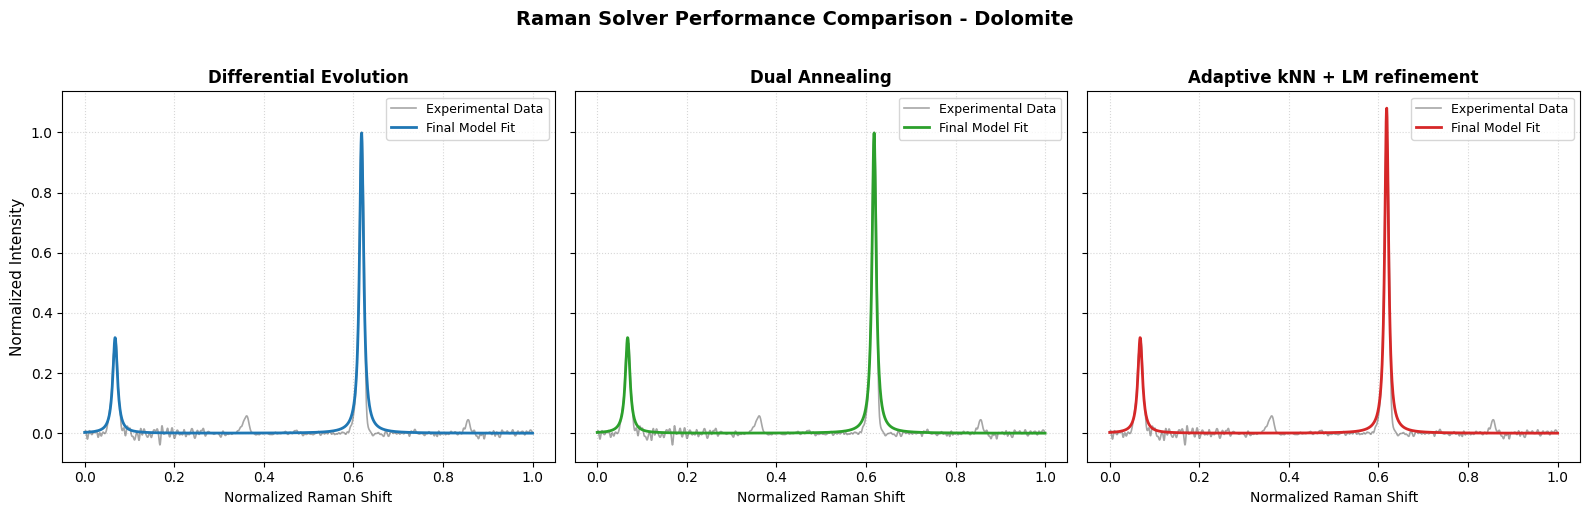

In [116]:
# ... [Your script running Solver 1, Solver 2, and Solver 3]

# Generate the single unified grid image file
plot_and_save_unified_grid(
    target_x=target_x,
    target_y=target_y,
    de_peaks=de_peaks,
    da_peaks=da_peaks,
    knn_peaks=knn_peaks,
    filename="dolomite_grid_comparison.png"
)

# Iron Oxide 1

Spectrum plot cleanly rendered and saved to 'Iron_Oxide_raw_spectrum.png'


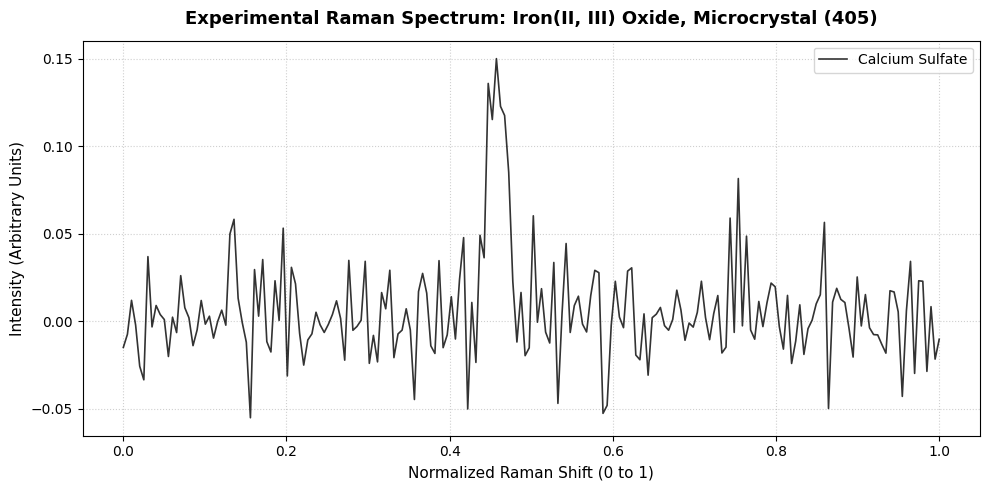

Total processed data points: 200


In [7]:
import csv
import numpy as np
import matplotlib.pyplot as plt

data = []

with open('real_examples/csvs/Iron(II,III)Oxide_405.csv', mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        data.append(row)

points = data[16:]
x = np.zeros(len(points))
y = np.zeros(len(points))
for i in range(len(points)):
    x[i] += np.float32(points[i][0])
    y[i] += np.float32(points[i][1])

cropped_x = x[380:580]
target_x = np.linspace(0, 1, len(cropped_x))
target_y = y[380:580]

# --- PLOTTING, LABELLING, AND SAVING ---
plt.figure(figsize=(10, 5))
plt.plot(target_x, target_y, color='black', linewidth=1.2, alpha=0.8, label='Calcium Sulfate')

# Add descriptive titles and labels
plt.title("Experimental Raman Spectrum: Iron(II, III) Oxide, Microcrystal (405)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Normalized Raman Shift (0 to 1)", fontsize=11)
plt.ylabel("Intensity (Arbitrary Units)", fontsize=11)

# Add clean styling elements
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

# Save the spectrum plot as a high-resolution image file
output_filename = "Iron_Oxide_raw_spectrum.png"
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"Spectrum plot cleanly rendered and saved to '{output_filename}'")

# Display the output window
plt.show()

print(f"Total processed data points: {len(target_y)}")

In [8]:
import csv
import time
import heapq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lmfit import Model, Parameters

def lorentzian(x, x0, gamma, maximum):
    gamma_sq = gamma ** 2
    return (maximum * gamma_sq) / (gamma_sq + (x - x0)**2)

def composite_lorentzian_model(x, **params):
    """Sums multiple Lorentzians based on parameter prefixes (p0_, p1_, etc.)"""
    y = np.zeros_like(x)
    prefixes = sorted(set(p.split('_')[0] for p in params.keys()))
    for pref in prefixes:
        y += lorentzian(x, params[f'{pref}_x0'], params[f'{pref}_gamma'], params[f'{pref}_maximum'])
    return y

# =====================================================================
# 1. OPTIMIZER WRAPPERS & FORMATTING
# =====================================================================

def fit_raman_spectrum(target_x, target_y, num_peaks, base_parameters, method='differential_evolution'):
    """
    Fits a cropped/normalized spectrum using standard lmfit global optimization algorithms.
    """
    model = Model(composite_lorentzian_model)
    pars = Parameters()
    
    for i in range(num_peaks):
        pref = f"p{i}_"
        init_x0 = (base_parameters["center_range"][0] + base_parameters["center_range"][1]) / 2
        init_gamma = (base_parameters["gamma_range"][0] + base_parameters["gamma_range"][1]) / 2
        init_max = (base_parameters["amplitude_range"][0] + base_parameters["amplitude_range"][1]) / 2
        
        pars.add(f"{pref}x0", value=init_x0, min=base_parameters["center_range"][0], max=base_parameters["center_range"][1])
        pars.add(f"{pref}gamma", value=init_gamma, min=base_parameters["gamma_range"][0], max=base_parameters["gamma_range"][1])
        pars.add(f"{pref}maximum", value=init_max, min=base_parameters["amplitude_range"][0], max=base_parameters["amplitude_range"][1])
        
    res = model.fit(target_y, pars, x=target_x, method=method, calc_covar=False)
    
    fitted_peaks = []
    best_values = res.params.valuesdict()
    for i in range(num_peaks):
        pref = f"p{i}_"
        fitted_peaks.append({
            "peak_id": i,
            "center": best_values[f"{pref}x0"],
            "gamma": best_values[f"{pref}gamma"],
            "amplitude": best_values[f"{pref}maximum"]
        })
        
    return fitted_peaks

def fit_with_custom_knn_pipeline(target_x, target_y, num_peaks, base_parameters, samples=1000, k=5, rounds=4, eps=0.15):
    """
    Wraps your custom persistent KNN stage followed by Levenberg-Marquardt local refinement.
    """
    # Execute Stage 1: Core KNN Global Search Space Approximation
    _, neighbors = knnFit_persistent(
        samples=samples, base_parameters=base_parameters, target_x=target_x, 
        target_y=target_y, num_peaks=num_peaks, k=k, rounds=rounds, eps=eps
    )
    
    # Execute Stage 2: Sub-domain Optimization Refinement via Levenberg-Marquardt
    best_res, nfe = refine_knn_with_lmfit(neighbors, target_x, target_y)
    
    # Parse lmfit ModelResult structure back to aligned peak lists
    fitted_peaks = []
    best_values = best_res.params.valuesdict()
    for i in range(num_peaks):
        pref = f"p{i}_"
        fitted_peaks.append({
            "peak_id": i,
            "center": best_values[f"{pref}x0"],
            "gamma": best_values[f"{pref}gamma"],
            "amplitude": best_values[f"{pref}maximum"]
        })
        
    return fitted_peaks

def print_formatted_peaks(method_name, runtime, peaks):
    """Prints optimization output in a beautiful, structured table format."""
    print("\n" + "="*50)
    print(f" METHOD: {method_name}")
    print(f" Runtime: {runtime:.4f} seconds")
    print("-"*50)
    print(f"{'Peak ID':<10} | {'Center (x0)':<12} | {'Gamma (γ)':<10} | {'Amplitude':<10}")
    print("-"*50)
    for p in peaks:
        print(f"Peak {p['peak_id']:<5} | {p['center']:<12.5f} | {p['gamma']:<10.5f} | {p['amplitude']:<10.5f}")
    print("="*50)

In [14]:
raman_params = {
    "center_range": (0.05, 0.9),
    "amplitude_range": (0.01, 1.0),
    "gamma_range": (0.003, 0.05),
    "x_min": 0,
    "x_max": 1
}

num_peaks_to_find = 1

# --- Solver 1: Differential Evolution ---
print("Running Differential Evolution...")
t0 = time.perf_counter()
de_peaks = fit_raman_spectrum(
    target_x=target_x, target_y=target_y, num_peaks=num_peaks_to_find,
    base_parameters=raman_params, method='differential_evolution'
)
de_runtime = time.perf_counter() - t0
print_formatted_peaks("Differential Evolution", de_runtime, de_peaks)


# --- Solver 2: Dual Annealing ---
print("\nRunning Dual Annealing...")
t0 = time.perf_counter()
da_peaks = fit_raman_spectrum(
    target_x=target_x, target_y=target_y, num_peaks=num_peaks_to_find,
    base_parameters=raman_params, method='dual_annealing'
)
da_runtime = time.perf_counter() - t0
print_formatted_peaks("Dual Annealing", da_runtime, da_peaks)


# --- Solver 3: Your Custom KNN + LM Refinement ---
print("\nRunning Custom KNN + LM Pipeline...")
t0 = time.perf_counter()
knn_peaks = fit_with_custom_knn_pipeline(
    target_x=target_x, target_y=target_y, num_peaks=num_peaks_to_find,
    base_parameters=raman_params, samples=1000, k=5, rounds=4, eps=0.15
)
knn_runtime = time.perf_counter() - t0
print_formatted_peaks("KNN + LM Refinement", knn_runtime, knn_peaks)

Running Differential Evolution...

 METHOD: Differential Evolution
 Runtime: 0.1573 seconds
--------------------------------------------------
Peak ID    | Center (x0)  | Gamma (γ)  | Amplitude 
--------------------------------------------------
Peak 0     | 0.45771      | 0.01121    | 0.15680   

Running Dual Annealing...

 METHOD: Dual Annealing
 Runtime: 0.7681 seconds
--------------------------------------------------
Peak ID    | Center (x0)  | Gamma (γ)  | Amplitude 
--------------------------------------------------
Peak 0     | 0.45771      | 0.01121    | 0.15680   

Running Custom KNN + LM Pipeline...

 METHOD: KNN + LM Refinement
 Runtime: 0.0549 seconds
--------------------------------------------------
Peak ID    | Center (x0)  | Gamma (γ)  | Amplitude 
--------------------------------------------------
Peak 0     | 0.45771      | 0.01121    | 0.15680   


In [17]:
def plot_and_save_unified_grid(target_x, target_y, de_peaks, da_peaks, knn_peaks, filename="raman_solvers_grid.png"):
    """
    Plots the real data against the final model fits for all three optimization methods 
    side-by-side in a single row layout, then saves the complete grid as one unified image.
    
    Args:
        target_x (array): The normalized X-axis range array.
        target_y (array): The experimental normalized spectrum intensity values.
        de_peaks (list): Fitted parameters list from Differential Evolution.
        da_peaks (list): Fitted parameters list from Dual Annealing.
        knn_peaks (list): Fitted parameters list from your Custom KNN pipeline.
        filename (str): Output image filename path.
    """
    # Create a single figure canvas composed of 1 row and 3 columns of subplots
    # sharey=True forces all windows to use the exact same Y-axis scale for fairness
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    
    # Map configurations for iterating dynamically through the subplot columns
    methods_config = [
        {"name": "Differential Evolution", "peaks": de_peaks, "color": "#1f77b4"},
        {"name": "Dual Annealing", "peaks": da_peaks, "color": "#2ca02c"},
        {"name": "Adaptive kNN + LM refinement", "peaks": knn_peaks, "color": "#d62728"}
    ]
    
    for idx, config in enumerate(methods_config):
        ax = axes[idx] # Focus on the active column subplot window
        
        # 1. Plot the common background raw experimental line reference
        ax.plot(target_x, target_y, color='black', alpha=0.35, linewidth=1.2, label='Experimental Data')
        
        # 2. Re-calculate the specific solver's total integrated curve array
        total_fitted_y = np.zeros_like(target_x)
        for p in config["peaks"]:
            total_fitted_y += lorentzian(target_x, p['center'], p['gamma'], p['amplitude'])
            
        # 3. Overlay the clean continuous model fit on top
        ax.plot(target_x, total_fitted_y, color=config["color"], linewidth=2, label='Final Model Fit')
        
        # 4. Styling individual sub-windows
        ax.set_title(config["name"], fontsize=12, fontweight='bold')
        ax.set_xlabel("Normalized Raman Shift", fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.5)
        
        # Place a separate, clean legend in the upper right corner of each panel
        ax.legend(loc='upper right', frameon=True, fontsize=9)
        
    # Apply standard Y-axis label specifically to the first column panel
    axes[0].set_ylabel("Normalized Intensity", fontsize=11)
    
    # Global overall chart adjustments
    plt.suptitle("Raman Solver Performance Comparison - Iron(II, III) Oxide", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save the entire grid layout securely to a single high-resolution file
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Successfully compiled grid canvas and saved image to '{filename}'")
    
    plt.show()

Successfully compiled grid canvas and saved image to 'Iron_Oxide_1_grid_comparison.png'


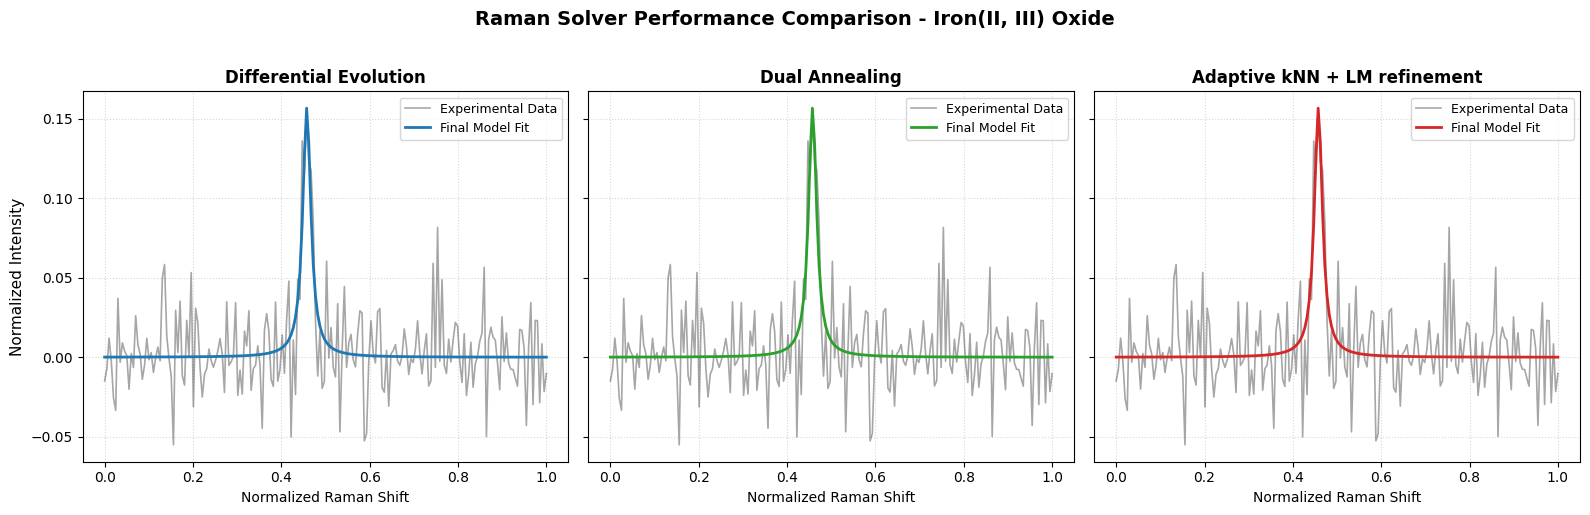

In [18]:
# ... [Your script running Solver 1, Solver 2, and Solver 3]

# Generate the single unified grid image file
plot_and_save_unified_grid(
    target_x=target_x,
    target_y=target_y,
    de_peaks=de_peaks,
    da_peaks=da_peaks,
    knn_peaks=knn_peaks,
    filename="Iron_Oxide_1_grid_comparison.png"
)

Spectrum plot cleanly rendered and saved to 'Iron_Oxide_2_raw_spectrum.png'


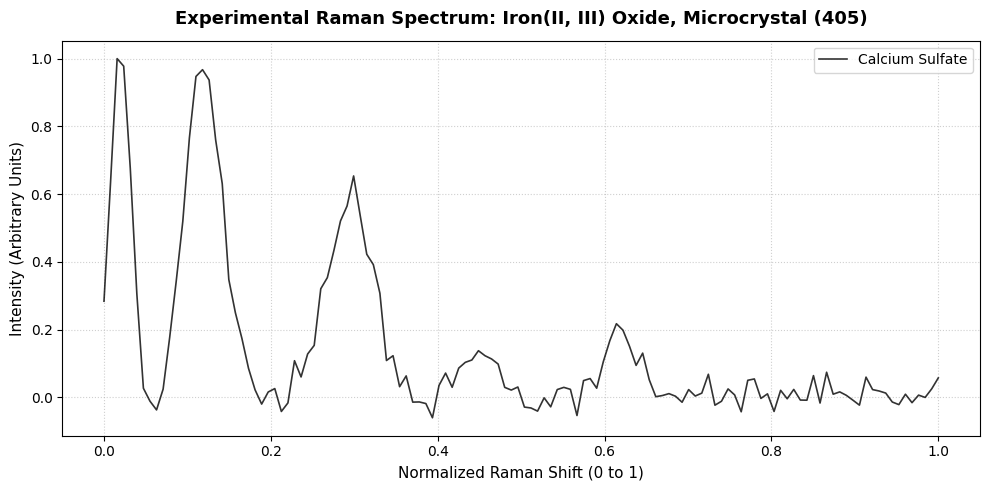

Total processed data points: 128


In [23]:
import csv
import numpy as np
import matplotlib.pyplot as plt

data = []

with open('real_examples/csvs/Iron(II,III)Oxide_405.csv', mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        data.append(row)

points = data[16:]
x = np.zeros(len(points))
y = np.zeros(len(points))
for i in range(len(points)):
    x[i] += np.float32(points[i][0])
    y[i] += np.float32(points[i][1])

cropped_x = x[:128]
target_x = np.linspace(0, 1, len(cropped_x))
target_y = y[:128]

# --- PLOTTING, LABELLING, AND SAVING ---
plt.figure(figsize=(10, 5))
plt.plot(target_x, target_y, color='black', linewidth=1.2, alpha=0.8, label='Calcium Sulfate')

# Add descriptive titles and labels
plt.title("Experimental Raman Spectrum: Iron(II, III) Oxide, Microcrystal (405)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Normalized Raman Shift (0 to 1)", fontsize=11)
plt.ylabel("Intensity (Arbitrary Units)", fontsize=11)

# Add clean styling elements
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

# Save the spectrum plot as a high-resolution image file
output_filename = "Iron_Oxide_2_raw_spectrum.png"
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"Spectrum plot cleanly rendered and saved to '{output_filename}'")

# Display the output window
plt.show()

print(f"Total processed data points: {len(target_y)}")

In [26]:
raman_params = {
    "center_range": (0.0, 0.9),
    "amplitude_range": (0.01, 1.0),
    "gamma_range": (0.003, 0.05),
    "x_min": 0,
    "x_max": 1
}

num_peaks_to_find = 5

# --- Solver 1: Differential Evolution ---
print("Running Differential Evolution...")
t0 = time.perf_counter()
de_peaks = fit_raman_spectrum(
    target_x=target_x, target_y=target_y, num_peaks=num_peaks_to_find,
    base_parameters=raman_params, method='differential_evolution'
)
de_runtime = time.perf_counter() - t0
print_formatted_peaks("Differential Evolution", de_runtime, de_peaks)


# --- Solver 2: Dual Annealing ---
print("\nRunning Dual Annealing...")
t0 = time.perf_counter()
da_peaks = fit_raman_spectrum(
    target_x=target_x, target_y=target_y, num_peaks=num_peaks_to_find,
    base_parameters=raman_params, method='dual_annealing'
)
da_runtime = time.perf_counter() - t0
print_formatted_peaks("Dual Annealing", da_runtime, da_peaks)


# --- Solver 3: Your Custom KNN + LM Refinement ---
print("\nRunning Custom KNN + LM Pipeline...")
t0 = time.perf_counter()
knn_peaks = fit_with_custom_knn_pipeline(
    target_x=target_x, target_y=target_y, num_peaks=num_peaks_to_find,
    base_parameters=raman_params, samples=1000, k=5, rounds=4, eps=0.15
)
knn_runtime = time.perf_counter() - t0
print_formatted_peaks("KNN + LM Refinement", knn_runtime, knn_peaks)

Running Differential Evolution...

 METHOD: Differential Evolution
 Runtime: 6.6150 seconds
--------------------------------------------------
Peak ID    | Center (x0)  | Gamma (γ)  | Amplitude 
--------------------------------------------------
Peak 0     | 0.61892      | 0.00485    | 0.31293   
Peak 1     | 0.00755      | 0.00591    | 0.52684   
Peak 2     | 0.02098      | 0.00776    | 0.96847   
Peak 3     | 0.29901      | 0.02774    | 0.67734   
Peak 4     | 0.12014      | 0.01881    | 0.99843   

Running Dual Annealing...

 METHOD: Dual Annealing
 Runtime: 4.9818 seconds
--------------------------------------------------
Peak ID    | Center (x0)  | Gamma (γ)  | Amplitude 
--------------------------------------------------
Peak 0     | 0.29626      | 0.02485    | 0.64083   
Peak 1     | 0.01926      | 0.01210    | 1.00000   
Peak 2     | 0.10820      | 0.01192    | 0.70813   
Peak 3     | 0.12940      | 0.01450    | 0.73439   
Peak 4     | 0.61829      | 0.01698    | 0.21701   

Ru

Successfully compiled grid canvas and saved image to 'Iron_Oxide_2_grid_comparison.png'


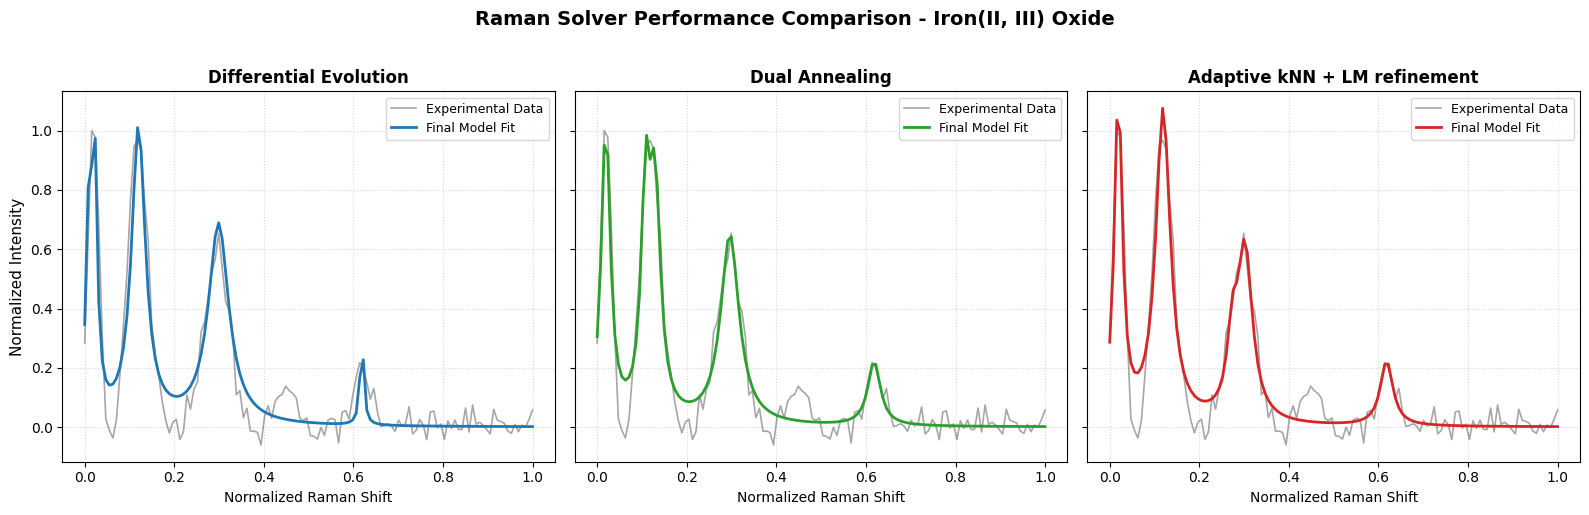

In [27]:
# ... [Your script running Solver 1, Solver 2, and Solver 3]

# Generate the single unified grid image file
plot_and_save_unified_grid(
    target_x=target_x,
    target_y=target_y,
    de_peaks=de_peaks,
    da_peaks=da_peaks,
    knn_peaks=knn_peaks,
    filename="Iron_Oxide_2_grid_comparison.png"
)